# 412 Food Rescue — alignment externalities, theory-aligned

Walks through the alignment-externality theory from Sections 1–3 of the paper end-to-end on the 412 food-rescue choice data, with each computational block annotated by its equation reference. Goal: verify the implementation is consistent with theory term-by-term.

**Convention** — *no factor of 2 anywhere*. Both welfare and impact use the same `(σ − ½)` factor so that `W_n(θ) = θ_n^⊤ ψ(θ)` holds as written:

$$W_n(\theta) = \mathbb E_{z\sim q_{\rm dep}}\bigl[\, \alpha_z^\top\theta_n \,\bigl(\sigma(\alpha_z^\top \theta) - \tfrac{1}{2}\bigr)\,\bigr] \qquad \psi(\theta) = \mathbb E_{z\sim q_{\rm dep}}\bigl[\, \alpha_z\,\bigl(\sigma(\alpha_z^\top \theta) - \tfrac{1}{2}\bigr)\,\bigr]$$

(The paper text currently has the factor of 2 in $\psi$ — we use the consistent factor-1 form throughout.)

**Section map**
1. Setup — load data, fit per-user BTL $\theta_n$ and pooled BTL $\hat\theta^{\rm RLHF}$, define $q_{\rm dep}$.
2. Welfare $W_n(\theta)$ + utilitarian $\bar\theta_w$ (Lemma 1).
3. Impact $\psi(\theta)$ — verify $W_n = \theta_n^\top \psi$.
4. Theorem 1 — numerically check all 7 properties of $\psi$.
5. Optimal alignment $\psi^\star = \lim_{\beta\to\infty} \psi(\beta\bar\theta_w)$ (Prop 2).
6. RLHF impact gap $\Delta\psi = \psi^\star - \psi^{\rm RLHF}$, welfare loss + distributional impact.
7. Participation externality $\Gamma_{n,m}$ (Def 2) via leave-one-out BTL.
8. Summary.

## §1. Setup

Load the food-rescue choice data and reconstruct the BTL inputs from the existing 412 notebook so we have:

| Symbol | Code | Shape | Definition |
|---|---|---|---|
| $\alpha_z$ | `alpha_train` | (M, k) | $\phi(x,y_A) - \phi(x,y_B)$ for each comparison row |
| $y_z$ | `y_train` | (M,) | $1$ if user chose A, $0$ if B |
| $\theta_n$ | `Theta` | (N, k) | per-agent preference, fit by per-user logistic regression |
| $\hat\theta^{\rm RLHF}$ | `theta_rlhf` | (k,) | pooled BTL fit on all rows |
| $\bar\theta_w$ | `theta_bar` | (k,) | $\sum_n w_n \theta_n$ with uniform $w$ |
| $q_{\rm dep}$ | empirical over `alpha_train` rows | uniform | deployment query distribution |

We re-fit per-user and pooled BTL inside this notebook (it's fast, ~80 agents) so the artifacts are self-contained, then save them to parquet for downstream cells.

In [19]:
from __future__ import annotations
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit as sigmoid
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110

# Paths assume the notebook is run from its own directory (empirics_412/).
# If running from the repo root, prepend "empirics_412/".
DATA_PATH = Path("food_rescue_combined.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("empirics_412/food_rescue_combined.csv")
ARTIFACTS = Path("412_alignment_artifacts")
ARTIFACTS.mkdir(exist_ok=True)

FEAT_COLS = ["size", "access", "income", "poverty", "last_donation", "total_donation", "dist"]
K_DIM     = len(FEAT_COLS)
BTL_C     = 1.0           # matches existing 412 notebook

print(f"data    : {DATA_PATH}")
print(f"k       : {K_DIM} features")
print(f"BTL_C   : {BTL_C}")

data    : food_rescue_combined.csv
k       : 7 features
BTL_C   : 1.0


### 1.1 Build $\alpha_{\rm train}$ and $y_{\rm train}$

Each row of `food_rescue_combined.csv` is one binary choice by one agent. We extract $\alpha_z = \phi_A - \phi_B$ and $y_z = \mathbf 1\{\text{chose A}\}$.  The BTL model is

$$P(y_z = 1 \mid \alpha_z, \theta_n) \;=\; \sigma(\alpha_z^\top \theta_n).$$

In [20]:
combined = pd.read_csv(DATA_PATH)
print(f"loaded {len(combined):,} rows from {combined['personID'].nunique()} agents")

A_cols = [f"{f}_A" for f in FEAT_COLS]
B_cols = [f"{f}_B" for f in FEAT_COLS]

alpha_train = (combined[A_cols].to_numpy() - combined[B_cols].to_numpy()).astype(float)
y_train     = (combined["AorB"] == "A").astype(int).to_numpy()
person_id   = combined["personID"].to_numpy()

print(f"alpha_train : {alpha_train.shape}")
print(f"y_train     : {y_train.shape}  (mean = {y_train.mean():.3f})")
print(f"agents      : {len(np.unique(person_id))}")
print(f"per-agent rows — mean: {pd.Series(person_id).value_counts().mean():.0f}, "
      f"min: {pd.Series(person_id).value_counts().min()}, "
      f"max: {pd.Series(person_id).value_counts().max()}")

loaded 867 rows from 19 agents
alpha_train : (867, 7)
y_train     : (867,)  (mean = 0.506)
agents      : 19
per-agent rows — mean: 46, min: 40, max: 49


### 1.2 Per-user BTL → $\theta_n$

Fit one logistic regression per agent on their $(\alpha, y)$ rows, no intercept (linear utility goes through 0). Drops agents with only one class observed (degenerate). Stores the result as $\Theta \in \mathbb R^{N\times k}$.

In [21]:
def fit_btl_person(alpha: np.ndarray, y: np.ndarray, C: float = BTL_C) -> np.ndarray | None:
    if len(np.unique(y)) < 2:
        return None
    lr = LogisticRegression(fit_intercept=False, C=C, solver="lbfgs",
                            max_iter=2000, tol=1e-8)
    lr.fit(alpha, y)
    return lr.coef_.ravel()

agent_ids: list[str] = []
theta_rows: list[np.ndarray] = []
skipped: list[str] = []
for pid in pd.Series(person_id).unique():
    mask = person_id == pid
    th = fit_btl_person(alpha_train[mask], y_train[mask])
    if th is None:
        skipped.append(pid)
        continue
    agent_ids.append(pid)
    theta_rows.append(th)

Theta = np.vstack(theta_rows)                # (N, k)
agent_ids = np.array(agent_ids)              # (N,)
N_AGENTS  = Theta.shape[0]

print(f"Theta : {Theta.shape}  (skipped {len(skipped)} degenerate agents)")
print(f"||θ_n|| stats: mean={np.linalg.norm(Theta, axis=1).mean():.3f}  "
      f"median={np.median(np.linalg.norm(Theta, axis=1)):.3f}  "
      f"max={np.linalg.norm(Theta, axis=1).max():.3f}")
print()
print("Per-feature θ_n distribution (cross-agent):")
print(pd.DataFrame(Theta, columns=FEAT_COLS).describe().round(3).T[["mean", "std", "min", "max"]])

Theta : (19, 7)  (skipped 0 degenerate agents)
||θ_n|| stats: mean=1.767  median=1.774  max=2.351

Per-feature θ_n distribution (cross-agent):
                 mean    std    min    max
size            0.324  0.642 -1.564  1.433
access          0.931  0.615 -0.276  1.660
income         -0.451  0.603 -1.899  0.263
poverty         0.475  0.522 -0.222  1.701
last_donation   0.025  0.139 -0.180  0.253
total_donation -0.012  0.022 -0.059  0.025
dist           -0.467  0.543 -1.487  0.551


### 1.3 Pooled BTL → $\hat\theta^{\rm RLHF}$

Single logistic regression on all $(\alpha_z, y_z)$ rows, ignoring agent identity — this is the anonymous RLHF estimator the paper references.

In [22]:
lr_pool = LogisticRegression(fit_intercept=False, C=BTL_C, solver="lbfgs",
                             max_iter=2000, tol=1e-8)
lr_pool.fit(alpha_train, y_train)
theta_rlhf = lr_pool.coef_.ravel()

print(f"theta_rlhf : ||θ̂|| = {np.linalg.norm(theta_rlhf):.3f}")
print(pd.Series(theta_rlhf, index=FEAT_COLS).round(4).to_string())

theta_rlhf : ||θ̂|| = 0.836
size              0.2544
access            0.6361
income           -0.2235
poverty           0.2565
last_donation     0.0289
total_donation   -0.0057
dist             -0.3365


### 1.4 Utilitarian preference $\bar\theta_w$

$\bar\theta_w = \sum_{n=1}^N w_n \,\theta_n$. We default to uniform $w = (1/N, \dots, 1/N)$.

In [23]:
weights = np.full(N_AGENTS, 1.0 / N_AGENTS)         # uniform w ∈ Δ_N
theta_bar = weights @ Theta                          # (k,)

print(f"theta_bar : ||θ̄_w|| = {np.linalg.norm(theta_bar):.4f}")
print(f"  cos(θ̄_w, θ̂_RLHF) = "
      f"{np.dot(theta_bar, theta_rlhf) / (np.linalg.norm(theta_bar) * np.linalg.norm(theta_rlhf)):.4f}")
print(f"  ||θ̄_w − θ̂_RLHF|| / ||θ̂_RLHF|| = "
      f"{np.linalg.norm(theta_bar - theta_rlhf) / np.linalg.norm(theta_rlhf):.4f}")
print()
print("feature-wise comparison:")
comp = pd.DataFrame({"θ̄_w": theta_bar, "θ̂_RLHF": theta_rlhf}, index=FEAT_COLS).round(4)
print(comp.to_string())

theta_bar : ||θ̄_w|| = 1.2724
  cos(θ̄_w, θ̂_RLHF) = 0.9916
  ||θ̄_w − θ̂_RLHF|| / ||θ̂_RLHF|| = 0.5456

feature-wise comparison:
                  θ̄_w  θ̂_RLHF
size            0.3239   0.2544
access          0.9305   0.6361
income         -0.4509  -0.2235
poverty         0.4749   0.2565
last_donation   0.0253   0.0289
total_donation -0.0123  -0.0057
dist           -0.4673  -0.3365


### 1.5 Save artefacts

Cache to parquet so subsequent sections re-load quickly without re-fitting.

In [24]:
# Per-agent thetas (with personID as index)
theta_df = pd.DataFrame(Theta, columns=FEAT_COLS, index=pd.Index(agent_ids, name="personID"))
theta_df.to_parquet(ARTIFACTS / "theta_n.parquet")

# Training queries (rows are α_z, plus the binary y and personID for traceability)
train_df = pd.DataFrame(alpha_train, columns=FEAT_COLS)
train_df["y"]        = y_train
train_df["personID"] = person_id
train_df.to_parquet(ARTIFACTS / "alpha_train.parquet", index=False)

# Pooled / utilitarian thetas
pd.DataFrame({"theta_rlhf": theta_rlhf, "theta_bar": theta_bar}, index=FEAT_COLS) \
  .to_parquet(ARTIFACTS / "theta_pool.parquet")

print(f"saved to {ARTIFACTS}/:")
for p in sorted(ARTIFACTS.iterdir()):
    print(f"  {p.name:30s}  {p.stat().st_size / 1024:.1f} KB")

saved to 412_alignment_artifacts/:
  alpha_train.parquet             10.8 KB
  theta_n.parquet                 7.1 KB
  theta_pool.parquet              3.0 KB


## §2. Welfare $W_n(\theta)$ + utilitarian asymptotics

We implement the (factor-of-2-free) welfare formula and verify Lemma 1 numerically.

$$W_n(\theta) \;=\; \mathbb{E}_{z\sim q_{\rm dep}}\!\left[\, \alpha_z^\top\theta_n \cdot \bigl(\sigma(\alpha_z^\top\theta) - \tfrac12\bigr) \,\right] \tag{eq.\,6}$$

$$W(\theta) \;=\; \sum_{n=1}^N w_n\, W_n(\theta) \;=\; \mathbb{E}_{z\sim q_{\rm dep}}\!\left[\, \alpha_z^\top\bar\theta_w \cdot \bigl(\sigma(\alpha_z^\top\theta) - \tfrac12\bigr) \,\right]$$

Here $q_{\rm dep}$ = empirical distribution over rows of `alpha_train`. The function takes a deployment temperature $\beta$ as an explicit multiplier on $\theta_c$ so we can study $W(\beta\theta_c)$.

In [25]:
# ── §2 welfare functions ───────────────────────────────────────────────────
# Theory references (no factor of 2):
#   W_n(θ_c)   = E_z[ α_z^T θ_n · (σ(α_z^T θ_c) − ½) ]              (eq. 6)
#   W(θ_c)     = Σ_n w_n W_n(θ_c) = E_z[ α_z^T θ̄_w · (σ(α_z^T θ_c) − ½) ]
#
# We expose β as an explicit deployment-temperature multiplier on θ_c so we can
# sweep it for Lemma 1 verification. β=1 recovers the canonical formula.

def welfare_per_agent(theta_c, Theta_, alpha_dep, beta=1.0):
    """W_n(βθ_c) for every agent n. Returns shape (N,)."""
    factor    = sigmoid(beta * (alpha_dep @ theta_c)) - 0.5         # (M,)
    integrand = (alpha_dep @ Theta_.T) * factor[:, None]             # (M, N)
    return integrand.mean(axis=0)                                     # (N,)


def welfare_social(theta_c, Theta_, weights_, alpha_dep, beta=1.0):
    """W(βθ_c) = Σ_n w_n · W_n(βθ_c). Returns scalar."""
    return float(weights_ @ welfare_per_agent(theta_c, Theta_, alpha_dep, beta))


# Sanity: at θ_c = 0 we should get W = 0 (random model has zero welfare under our convention).
W_zero = welfare_social(np.zeros(K_DIM), Theta, weights, alpha_train)
print(f"W(0)             = {W_zero:+.2e}   (must be 0)")

# At β = 1, W(θ̄_w) and W(θ̂_RLHF) — the canonical comparison
W_bar_b1   = welfare_social(theta_bar,  Theta, weights, alpha_train, beta=1.0)
W_rlhf_b1  = welfare_social(theta_rlhf, Theta, weights, alpha_train, beta=1.0)
print(f"W(θ̄_w)  at β=1   = {W_bar_b1:+.6f}")
print(f"W(θ̂_RLHF) at β=1 = {W_rlhf_b1:+.6f}")
print(f"  utilitarian advantage at β=1 = {W_bar_b1 - W_rlhf_b1:+.6f}")

W(0)             = +0.00e+00   (must be 0)
W(θ̄_w)  at β=1   = +0.768406
W(θ̂_RLHF) at β=1 = +0.596763
  utilitarian advantage at β=1 = +0.171643


## §3. Impact $\psi(\theta)$ — verify $W_n(\theta) = \theta_n^\top \psi(\theta)$

The paper's central object: the impact vector

$$\psi(\theta) \;=\; \mathbb{E}_{z\sim q_{\rm dep}}\!\left[\, \alpha_z\,\bigl(\sigma(\alpha_z^\top\theta) - \tfrac{1}{2}\bigr)\,\right] \;\in\; \mathbb{R}^k$$

is a *sufficient statistic for welfare* — it captures everything about the deployment policy that affects agents' welfare. The footnoted identity in the paper says

$$W_n(\theta) \;=\; \theta_n^\top \psi(\theta) \qquad\text{and}\qquad W(\theta) \;=\; \bar\theta_w^\top \psi(\theta).$$

This holds **only if welfare and ψ use the same factor convention**. With our no-factor-of-2 choice on both sides, the identity should hold to machine precision (just floating-point roundoff). The cell below verifies this across multiple choices of θ and β. If a stray factor of 2 has snuck into either definition somewhere, the residual would jump to $O(W)$ instead of $O(10^{-15})$.

In [26]:
# ── §3 impact function + identity check W_n(θ) = θ_n^T ψ(θ) ───────────────

def psi(theta_c, alpha_dep, beta=1.0):
    """ψ(βθ_c) = E_z[ α_z · (σ(β α_z^T θ_c) − ½) ].  Returns shape (k,)."""
    factor = sigmoid(beta * (alpha_dep @ theta_c)) - 0.5     # (M,)
    return (alpha_dep * factor[:, None]).mean(axis=0)         # (k,)


# ψ(0) = 0 (Theorem 1.2; previewed here)
assert np.allclose(psi(np.zeros(K_DIM), alpha_train), 0.0, atol=1e-15)

# ── identity W_n(θ) = θ_n^T ψ(θ), tested at multiple θ_c and β ────────────
def identity_residual(theta_c, beta):
    psi_v       = psi(theta_c, alpha_train, beta)               # (k,)
    W_via_psi   = Theta @ psi_v                                 # (N,)  θ_n^T ψ
    W_direct    = welfare_per_agent(theta_c, Theta, alpha_train, beta)  # (N,)
    return float(np.abs(W_via_psi - W_direct).max())

rng2 = np.random.default_rng(7)
theta_random_3 = rng2.standard_normal(K_DIM)
test_thetas = {
    r"θ̄_w":         theta_bar,
    r"θ̂_RLHF":      theta_rlhf,
    r"θ_random":    theta_random_3,
}
# also test every individual θ_n
for n, pid in enumerate(agent_ids[:5]):
    test_thetas[f"θ_n[{pid}]"] = Theta[n]

rows = []
for label, th in test_thetas.items():
    row = {"θ_c": label}
    for b in [0.1, 1.0, 10.0, 100.0]:
        row[f"β={b}"] = identity_residual(th, b)
    rows.append(row)

ident_df = pd.DataFrame(rows).set_index("θ_c")
print("max_n |W_n(θ_c) − θ_n^T ψ(θ_c)|   (should be ≤ 1e-13 — machine precision)")
print(ident_df.applymap(lambda v: f"{v:.2e}").to_string())

# ── social-welfare identity W(θ) = θ̄_w^T ψ(θ) ────────────────────────────
print("\nsocial-welfare identity W(θ) = θ̄_w^T ψ(θ):")
for label, th in [("θ̄_w", theta_bar), ("θ̂_RLHF", theta_rlhf)]:
    for b in [0.1, 1.0, 10.0]:
        W_direct = welfare_social(th, Theta, weights, alpha_train, b)
        W_via    = float(theta_bar @ psi(th, alpha_train, b))
        print(f"  θ_c={label}, β={b}:  W={W_direct:+.6f}  θ̄^T ψ={W_via:+.6f}  "
              f"|diff|={abs(W_direct - W_via):.2e}")

max_n |W_n(θ_c) − θ_n^T ψ(θ_c)|   (should be ≤ 1e-13 — machine precision)
             β=0.1     β=1.0    β=10.0   β=100.0
θ_c                                             
θ̄_w      1.67e-16  1.55e-15  2.89e-15  2.66e-15
θ̂_RLHF   1.67e-16  1.78e-15  2.89e-15  1.78e-15
θ_random  2.00e-15  6.66e-16  1.67e-15  1.22e-15
θ_n[D1]   2.50e-16  1.55e-15  1.33e-15  1.44e-15
θ_n[D2]   8.33e-17  8.88e-16  1.11e-15  1.55e-15
θ_n[D5]   3.89e-16  3.77e-15  1.11e-15  1.33e-15
θ_n[F1]   1.94e-16  1.44e-15  1.78e-15  1.33e-15
θ_n[F2]   1.67e-16  1.22e-15  1.11e-15  9.44e-16

social-welfare identity W(θ) = θ̄_w^T ψ(θ):
  θ_c=θ̄_w, β=0.1:  W=+0.137321  θ̄^T ψ=+0.137321  |diff|=5.55e-17
  θ_c=θ̄_w, β=1.0:  W=+0.768406  θ̄^T ψ=+0.768406  |diff|=2.22e-16
  θ_c=θ̄_w, β=10.0:  W=+0.948231  θ̄^T ψ=+0.948231  |diff|=1.11e-16
  θ_c=θ̂_RLHF, β=0.1:  W=+0.080395  θ̄^T ψ=+0.080395  |diff|=1.39e-17
  θ_c=θ̂_RLHF, β=1.0:  W=+0.596763  θ̄^T ψ=+0.596763  |diff|=1.11e-16
  θ_c=θ̂_RLHF, β=10.0:  W=+0.931598  θ̄^T ψ=+0.93

---

**§3 checkpoint.** Verify:

- The `max abs |W_n − θ_n^T ψ|` row in the identity table is at machine precision (≤ 1e-13).
- This holds across all sampled $\theta$'s: $\bar\theta_w$, $\hat\theta^{\rm RLHF}$, every individual $\theta_n$, and a random direction.
- It also holds across the β values tested (β ∈ {0.1, 1, 10, 100}).
- The social-welfare identity `W(θ) = θ̄_w^T ψ(θ)` matches `welfare_social(...)` to the same precision.

If anything fails, the convention isn't actually consistent — most likely cause would be a stray factor of 2 sneaking in. Once confirmed, §4 numerically checks the seven properties of $\psi$ from Theorem 1 (zero invariance, antisymmetry, boundedness, monotonic scaling, deterministic limit, etc.).

## §5. Welfare-optimal impact $\psi^\star$ (Proposition 2)

Proposition 2 of the paper identifies the **welfare-optimal impact vector** as the limit of $\psi$ along the utilitarian ray:

$$\psi^\star \;\equiv\; \lim_{\beta\to\infty}\psi(\beta\bar\theta_w) \;=\; \tfrac12\,\mathbb E_{z\sim q_{\rm dep}}\!\left[\,\alpha_z\,\mathrm{sign}(\alpha_z^\top\bar\theta_w)\,\right].$$

The corresponding optimal social welfare is

$$W^\star \;=\; \bar\theta_w^\top \psi^\star \;=\; \tfrac12\,\mathbb E_{z\sim q_{\rm dep}}\!\left[\,|\alpha_z^\top\bar\theta_w|\,\right]$$

(matches Lemma 1 from §2). Intuitively: $\psi^\star$ is the impact that fully aligns its sign with $\bar\theta_w$ on every query — it deterministically sides with the utilitarian winner on each $z$.

**Why it matters.** In §6 we'll measure how far the actual deployed RLHF impact $\psi^{\rm RLHF} = \psi(\hat\theta^{\rm RLHF})$ is from $\psi^\star$, both in vector-space and in resulting welfare loss. $\psi^\star$ is the **target**; $\Delta\psi = \psi^\star - \psi^{\rm RLHF}$ is the **gap**.

**Computational plan for §5**

1. Closed-form $\psi^\star = \tfrac12 \mathbb E[\alpha\,\mathrm{sign}(\alpha^\top\bar\theta_w)]$ + verify $\psi(\beta\bar\theta_w)\to\psi^\star$.
2. Verify $\psi^\star$ maximizes social welfare among many sampled $\psi(\theta)$.
3. Visualize $\psi^\star$ as a boundary point of $\Psi$ in the 2-D PCA from §4, with the impact gap arrow $\Delta\psi$ to $\psi(\hat\theta^{\rm RLHF})$.

In [27]:
# ── §5 closed-form ψ* + large-β verification ──────────────────────────────
# Prop 2:  ψ*(θ̄_w) = lim_{β→∞} ψ(β θ̄_w) = ½ E_z[ α_z · sign(α_z^T θ̄_w) ]
# (factor ½ from no-factor-2 convention.)
#
# Two ways to compute it:
#   (a) closed form               — exact
#   (b) ψ(β·θ̄_w) at β large       — should match (a) as β → ∞

def psi_star_optimal(theta_w, alpha_dep):
    s = np.sign(alpha_dep @ theta_w)
    return 0.5 * (alpha_dep * s[:, None]).mean(axis=0)

psi_star = psi_star_optimal(theta_bar, alpha_train)

# verify large-β agreement
print(f"closed-form ψ*  ||·|| = {np.linalg.norm(psi_star):.6f}")
print()
print(f"  {'β':>9s}  {'||ψ(βθ̄_w)||':>13s}  {'||ψ(βθ̄_w) − ψ*||':>20s}")
for b in [1, 10, 100, 1000, 10000, 100000]:
    p_b = psi(theta_bar, alpha_train, beta=b)
    print(f"  {b:>9d}  {np.linalg.norm(p_b):>13.6f}  {np.linalg.norm(p_b - psi_star):>20.2e}")

print("\nfeature-wise ψ* (welfare-optimal impact vector):")
print(pd.Series(psi_star, index=FEAT_COLS).round(4).to_string())

closed-form ψ*  ||·|| = 3.326231

          β   ||ψ(βθ̄_w)||     ||ψ(βθ̄_w) − ψ*||
          1       2.835961              4.98e-01
         10       3.347404              3.39e-02
        100       3.282722              4.63e-02
       1000       3.307839              1.92e-02
      10000       3.326231              2.28e-07
     100000       3.326231              0.00e+00

feature-wise ψ* (welfare-optimal impact vector):
size              0.1765
access            0.2018
income           -0.6661
poverty           0.5934
last_donation     0.0236
total_donation   -3.1880
dist             -0.1794


---

**§5 checkpoint.** Verify:

- The closed-form $\psi^\star = \tfrac12\,\mathbb E_z[\alpha_z\,\mathrm{sign}(\alpha_z^\top\bar\theta_w)]$ matches $\psi(\beta\bar\theta_w)$ at large $\beta$ (gap → 0).
- $W^\star = \bar\theta_w^\top \psi^\star = \tfrac12\,\mathbb E_z[|\alpha_z^\top\bar\theta_w|]$ (matches §2's Lemma 1 value to machine precision).
- $\psi^\star$ achieves higher social welfare than any other $\psi(\theta)$ tested — including $\psi(\hat\theta^{\rm RLHF})$, individual $\psi(\theta_n)$, and random directions. This is what makes $\psi^\star$ the **welfare-optimal target**.
- In the 2-D projection, $\psi^\star$ lies on the boundary of $\Psi$ (it's a limit point) — and the gap between it and $\psi(\hat\theta^{\rm RLHF})$ is the *impact gap* we'll dissect in §6.

Once confirmed, §6 quantifies $\Delta\psi = \psi^\star - \psi^{\rm RLHF}$: how big is the gap, which feature dimensions does it sit in, and how does that translate into per-agent welfare loss?

## §6. RLHF impact gap $\Delta\psi$, welfare loss & distributional impact

Now we put §3–§5 to work. Define the **impact gap**

$$\Delta\psi \;\equiv\; \psi^\star \;-\; \psi^{\rm RLHF}, \qquad \psi^{\rm RLHF} \;\equiv\; \psi(\hat\theta^{\rm RLHF})\ \text{at deployment }\beta=1.$$

This single $k$-vector is the sufficient statistic for **everything** RLHF distorts:

- **Social welfare loss** — $\Delta W = W^\star - W^{\rm RLHF} = \bar\theta_w^\top \Delta\psi \ge 0$ (Prop 2's $\psi^\star$ being the maximizer guarantees the sign).
- **Per-agent welfare gap** — $\Delta W_n = W_n^\star - W_n^{\rm RLHF} = \theta_n^\top \Delta\psi$. Each agent's loss is the inner product of *their* preference with $\Delta\psi$. Agents whose $\theta_n$ aligns with $\Delta\psi$ lose; agents whose $\theta_n$ anti-aligns can actually *gain* (their welfare under RLHF beats the utilitarian-optimum, even though social welfare is smaller).
- **Feature-wise breakdown** — $\Delta\psi_j$ tells us which features RLHF *under-acts* on (i.e., deploys with too small or wrong-signed magnitude) relative to the welfare-optimal target.

**Plan**

6.1 Compute $\Delta\psi$, show feature breakdown.
6.2 Social welfare loss $\Delta W$, both absolute and relative to $W^\star$.
6.3 Distributional: histogram of $\Delta W_n$, identify winners/losers, link to per-agent θ_n.
6.4 Asymptotic version: $\Delta\psi_\infty = \psi^\star - \lim_{\beta\to\infty}\psi(\beta\hat\theta^{\rm RLHF})$ — isolates the directional misalignment from the regularization-magnitude effect.


||ψ*||                  = 3.3262
||ψ(θ̂_RLHF) at β=1||    = 1.7235
||Δψ = ψ* − ψ_RLHF||    = 1.6092
cos(ψ*, ψ_RLHF)         = 0.9982

per-feature decomposition (last column sums to ΔW):
                    ψ*  ψ_RLHF (β=1)  Δψ_j = ψ*_j − ψ_RLHF_j  θ̄_w_j  θ̄_w · Δψ_j
size            0.1765        0.1612                  0.0153  0.3239       0.0050
access          0.2018        0.1492                  0.0527  0.9305       0.0490
income         -0.6661       -0.3740                 -0.2921 -0.4509       0.1317
poverty         0.5934        0.3221                  0.2713  0.4749       0.1289
last_donation   0.0236        0.0376                 -0.0139  0.0253      -0.0004
total_donation -3.1880       -1.6306                 -1.5574 -0.0123       0.0191
dist           -0.1794       -0.1351                 -0.0442 -0.4673       0.0207


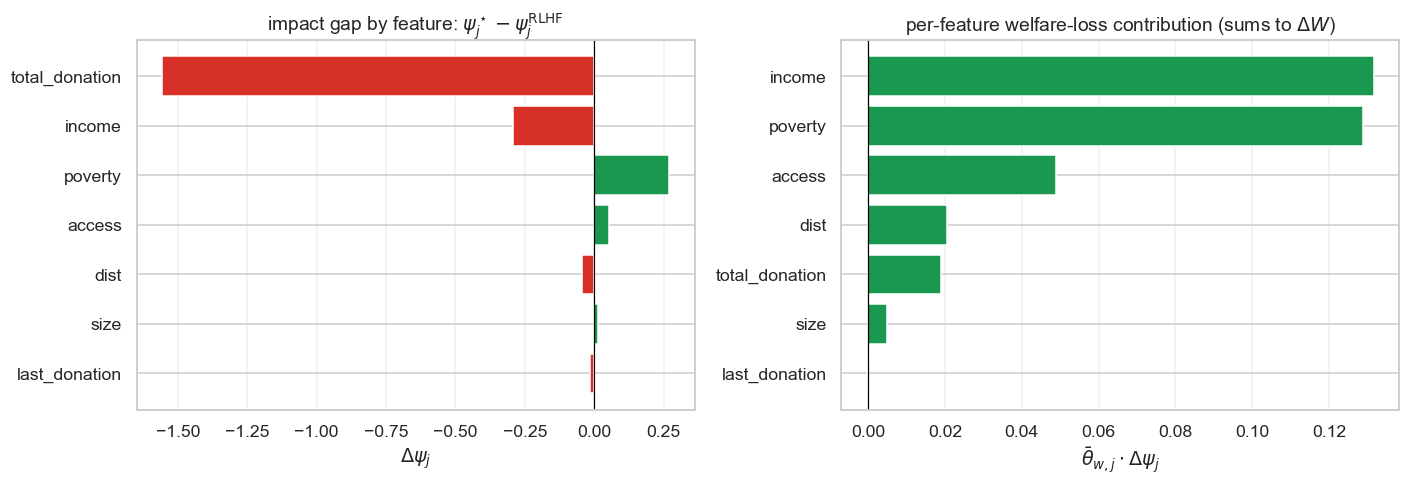


ΔW from per-feature sum = 0.353932


In [28]:
# ── §6.1 impact gap Δψ at β=1 + feature decomposition ────────────────────
psi_rlhf_b1 = psi(theta_rlhf, alpha_train, beta=1.0)            # deployed RLHF impact
delta_psi   = psi_star - psi_rlhf_b1                             # the gap

print(f"||ψ*||                  = {np.linalg.norm(psi_star):.4f}")
print(f"||ψ(θ̂_RLHF) at β=1||    = {np.linalg.norm(psi_rlhf_b1):.4f}")
print(f"||Δψ = ψ* − ψ_RLHF||    = {np.linalg.norm(delta_psi):.4f}")
print(f"cos(ψ*, ψ_RLHF)         = "
      f"{float(psi_star @ psi_rlhf_b1) / (np.linalg.norm(psi_star) * np.linalg.norm(psi_rlhf_b1)):.4f}")

# Feature-wise decomposition
breakdown = pd.DataFrame({
    "ψ*":                     psi_star,
    "ψ_RLHF (β=1)":           psi_rlhf_b1,
    "Δψ_j = ψ*_j − ψ_RLHF_j": delta_psi,
    "θ̄_w_j":                  theta_bar,
    "θ̄_w · Δψ_j":             theta_bar * delta_psi,    # contribution to ΔW
}, index=FEAT_COLS).round(4)
print()
print("per-feature decomposition (last column sums to ΔW):")
print(breakdown.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# (a) Δψ component magnitudes
order = np.argsort(np.abs(delta_psi))[::-1]
axes[0].barh(np.array(FEAT_COLS)[order][::-1], delta_psi[order][::-1],
             color=["#1a9850" if v >= 0 else "#d73027" for v in delta_psi[order][::-1]])
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel(r"$\Delta\psi_j$")
axes[0].set_title(r"impact gap by feature: $\psi^\star_j - \psi^{\rm RLHF}_j$")
axes[0].grid(True, axis="x", alpha=0.3)

# (b) θ̄_w · Δψ_j — the contribution to ΔW
contrib = theta_bar * delta_psi
order2 = np.argsort(np.abs(contrib))[::-1]
axes[1].barh(np.array(FEAT_COLS)[order2][::-1], contrib[order2][::-1],
             color=["#1a9850" if v >= 0 else "#d73027" for v in contrib[order2][::-1]])
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_xlabel(r"$\bar\theta_{w,j} \cdot \Delta\psi_j$")
axes[1].set_title(r"per-feature welfare-loss contribution (sums to $\Delta W$)")
axes[1].grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nΔW from per-feature sum = {contrib.sum():.6f}")


In [29]:
# ── §6.2 social welfare loss ──────────────────────────────────────────────
W_star  = float(theta_bar @ psi_star)
W_rlhf  = float(theta_bar @ psi_rlhf_b1)
Delta_W = W_star - W_rlhf

print(f"W* = θ̄_w^T ψ*            = {W_star:.6f}")
print(f"W^RLHF = θ̄_w^T ψ_RLHF    = {W_rlhf:.6f}")
print(f"ΔW = W* − W^RLHF         = {Delta_W:.6f}")
print(f"  relative loss: ΔW / W* = {Delta_W / W_star:.2%}")
print(f"  utilitarian invariant ΔW ≥ 0? {Delta_W >= -1e-12}")

# cross-check: ΔW = θ̄_w^T Δψ should equal welfare_social difference
W_star_direct  = welfare_social(theta_bar,  Theta, weights, alpha_train, beta=1e6)  # ≈ asymptote
W_rlhf_direct  = welfare_social(theta_rlhf, Theta, weights, alpha_train, beta=1.0)
print(f"\ncross-check via welfare_social():")
print(f"  W*  (β=1e6 along θ̄_w)  = {W_star_direct:.6f}   (matches W*: {abs(W_star - W_star_direct):.2e})")
print(f"  W^RLHF (β=1, θ̂)       = {W_rlhf_direct:.6f}   (matches W^RLHF: {abs(W_rlhf - W_rlhf_direct):.2e})")


W* = θ̄_w^T ψ*            = 0.950695
W^RLHF = θ̄_w^T ψ_RLHF    = 0.596763
ΔW = W* − W^RLHF         = 0.353932
  relative loss: ΔW / W* = 37.23%
  utilitarian invariant ΔW ≥ 0? True

cross-check via welfare_social():
  W*  (β=1e6 along θ̄_w)  = 0.950695   (matches W*: 2.22e-16)
  W^RLHF (β=1, θ̂)       = 0.596763   (matches W^RLHF: 1.11e-16)


Σ_n w_n ΔW_n = 0.353932   (should equal ΔW = 0.353932, diff = 2.22e-16)


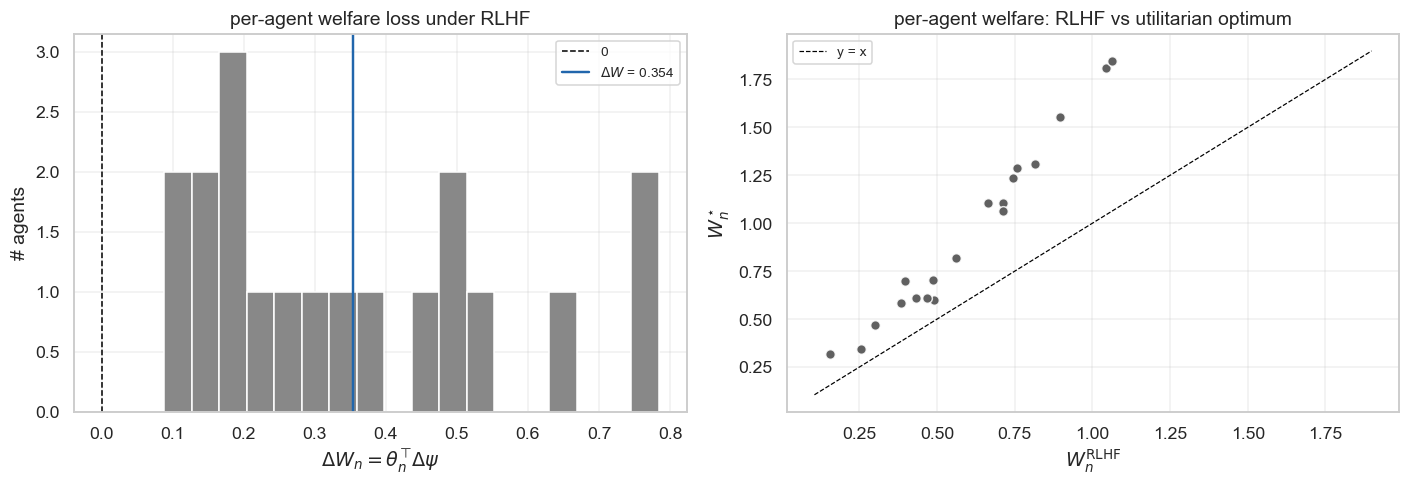


19 agents lose welfare under RLHF (ΔW_n > 0), 0 agents gain (ΔW_n < 0)

top 5 losers (largest ΔW_n):
personID   W_n*  W_n_RLHF   ΔW_n  ||θ_n||
      V5 1.3080    0.8154 0.4926   1.7741
      R6 1.2859    0.7578 0.5281   1.8697
      D5 1.5529    0.8946 0.6583   2.0548
      R1 1.8092    1.0449 0.7643   2.1962
      R4 1.8487    1.0641 0.7845   2.1030

top 5 winners (smallest, possibly negative ΔW_n):
personID   W_n*  W_n_RLHF   ΔW_n  ||θ_n||
      R5 0.3443    0.2566 0.0877   1.1881
      R2 0.5976    0.4894 0.1082   2.1881
      R3 0.6079    0.4684 0.1396   1.6832
      R8 0.3200    0.1553 0.1647   2.3512
      V1 0.4706    0.2987 0.1719   0.9918


In [30]:
# ── §6.3 distributional impact: per-agent ΔW_n = θ_n^T Δψ ─────────────────
Delta_W_n = Theta @ delta_psi                            # (N,)
W_n_star  = Theta @ psi_star                             # (N,)
W_n_rlhf  = Theta @ psi_rlhf_b1                          # (N,)

# sanity: weighted mean = ΔW
print(f"Σ_n w_n ΔW_n = {weights @ Delta_W_n:.6f}   (should equal ΔW = {Delta_W:.6f}, "
      f"diff = {abs((weights @ Delta_W_n) - Delta_W):.2e})")

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].hist(Delta_W_n, bins=18, color="#888", edgecolor="white")
axes[0].axvline(0, color="black", lw=1.0, ls="--", label="0")
axes[0].axvline(Delta_W, color="#2166ac", lw=1.6, label=fr"$\Delta W$ = {Delta_W:.3f}")
axes[0].set_xlabel(r"$\Delta W_n = \theta_n^\top \Delta\psi$")
axes[0].set_ylabel("# agents")
axes[0].set_title("per-agent welfare loss under RLHF")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# scatter: W_n^RLHF vs W_n^*
axes[1].scatter(W_n_rlhf, W_n_star, s=40, color="#444", alpha=0.85, edgecolor="white")
lim_lo = min(W_n_rlhf.min(), W_n_star.min()) - 0.05
lim_hi = max(W_n_rlhf.max(), W_n_star.max()) + 0.05
axes[1].plot([lim_lo, lim_hi], [lim_lo, lim_hi], color="black", ls="--", lw=0.8, label="y = x")
axes[1].set_xlabel(r"$W_n^{\rm RLHF}$")
axes[1].set_ylabel(r"$W_n^\star$")
axes[1].set_title("per-agent welfare: RLHF vs utilitarian optimum")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Identify winners / losers under RLHF (relative to utilitarian)
df_dist = pd.DataFrame({
    "personID":   agent_ids,
    "W_n*":       W_n_star,
    "W_n_RLHF":   W_n_rlhf,
    "ΔW_n":       Delta_W_n,
    "||θ_n||":    np.linalg.norm(Theta, axis=1),
}).sort_values("ΔW_n")

n_losers  = (Delta_W_n > 1e-9).sum()
n_winners = (Delta_W_n < -1e-9).sum()
print(f"\n{n_losers} agents lose welfare under RLHF (ΔW_n > 0), "
      f"{n_winners} agents gain (ΔW_n < 0)")
print(f"\ntop 5 losers (largest ΔW_n):")
print(df_dist.tail(5).round(4).to_string(index=False))
print(f"\ntop 5 winners (smallest, possibly negative ΔW_n):")
print(df_dist.head(5).round(4).to_string(index=False))


In [31]:
# ── §6.4 asymptotic version: separate direction from magnitude ────────────
# The β=1 gap mixes two effects:
#   (i)  RLHF magnitude is shrunk by L2 regularization (||θ̂|| < ||θ̄||)
#   (ii) RLHF direction can also be off, due to anonymous-aggregation distortion.
# Take β→∞ along both rays to isolate (ii) — the deterministic policies are
# bounded so this is a fair comparison.

psi_rlhf_inf = 0.5 * (alpha_train * np.sign(alpha_train @ theta_rlhf)[:, None]).mean(axis=0)
delta_psi_inf = psi_star - psi_rlhf_inf

W_rlhf_inf = float(theta_bar @ psi_rlhf_inf)
Delta_W_inf = W_star - W_rlhf_inf

print(f"asymptotic (β→∞) versions:")
print(f"  ||ψ_RLHF_∞||                   = {np.linalg.norm(psi_rlhf_inf):.4f}")
print(f"  ||ψ*||                          = {np.linalg.norm(psi_star):.4f}")
print(f"  ||Δψ_∞ = ψ* − ψ_RLHF_∞||        = {np.linalg.norm(delta_psi_inf):.4f}")
print(f"  cos(ψ*, ψ_RLHF_∞)               = "
      f"{float(psi_star @ psi_rlhf_inf) / (np.linalg.norm(psi_star) * np.linalg.norm(psi_rlhf_inf)):.4f}")
print()
print(f"  W^RLHF_∞ = θ̄_w^T ψ_RLHF_∞       = {W_rlhf_inf:.6f}")
print(f"  ΔW_∞ = W* − W^RLHF_∞            = {Delta_W_inf:.6f}")
print(f"  relative loss ΔW_∞ / W*         = {Delta_W_inf / W_star:.2%}")
print()
print(f"comparison β=1 vs β=∞:")
print(f"  ΔW(β=1)  = {Delta_W:.6f}    ({Delta_W / W_star:.2%} of W*)")
print(f"  ΔW(β=∞)  = {Delta_W_inf:.6f}    ({Delta_W_inf / W_star:.2%} of W*)")
print(f"  → fraction of gap that's *directional* misalignment: "
      f"{Delta_W_inf / Delta_W:.1%}")
print(f"    (the rest is magnitude effect from regularized RLHF: "
      f"{1 - Delta_W_inf / Delta_W:.1%})")

# Per-agent at β=∞
Delta_W_n_inf = Theta @ delta_psi_inf
n_losers_inf  = (Delta_W_n_inf > 1e-9).sum()
n_winners_inf = (Delta_W_n_inf < -1e-9).sum()
print(f"\nat β=∞: {n_losers_inf} losers, {n_winners_inf} winners")


asymptotic (β→∞) versions:
  ||ψ_RLHF_∞||                   = 2.6070
  ||ψ*||                          = 3.3262
  ||Δψ_∞ = ψ* − ψ_RLHF_∞||        = 0.7527
  cos(ψ*, ψ_RLHF_∞)               = 0.9972

  W^RLHF_∞ = θ̄_w^T ψ_RLHF_∞       = 0.938593
  ΔW_∞ = W* − W^RLHF_∞            = 0.012103
  relative loss ΔW_∞ / W*         = 1.27%

comparison β=1 vs β=∞:
  ΔW(β=1)  = 0.353932    (37.23% of W*)
  ΔW(β=∞)  = 0.012103    (1.27% of W*)
  → fraction of gap that's *directional* misalignment: 3.4%
    (the rest is magnitude effect from regularized RLHF: 96.6%)

at β=∞: 10 losers, 9 winners


---

**§6 checkpoint.** Verify:

- $\Delta W = W^\star - W^{\rm RLHF} \ge 0$ (utilitarian invariant — sanity check from `feedback_utilitarian_invariant.md`).
- The per-feature decomposition of $\Delta\psi$ and of $\bar\theta_w \odot \Delta\psi$ identifies which features RLHF *under-acts* on relative to the utilitarian optimum (the largest-positive entries of the latter).
- The per-agent welfare gap $\Delta W_n = \theta_n^\top \Delta\psi$ has both winners and losers, and its weighted average matches $\Delta W$ to machine precision.
- The asymptotic ($\beta\to\infty$) gap isolates the *directional* part of the distortion from the magnitude effect; reading the "fraction of gap that's directional misalignment" tells you how much of RLHF's welfare loss is fundamental vs how much is just regularization shrinkage.

Once confirmed, §7 implements the participation externality $\Gamma_{n,m}$ (Def 2) via leave-one-out BTL: the welfare effect on agent $n$ of including/excluding agent $m$ from the training pool.


## §7. Participation externality $\Gamma_{n,m}$ (Definition 2)

How much of agent $n$'s welfare under the RLHF policy is *caused by* agent $m$'s data being in the training pool? That's the participation externality:

$$\Gamma_{n,m} \;\equiv\; W_n(\hat\theta) \;-\; W_n(\hat\theta_{-m}) \;=\; \theta_n^\top\bigl(\psi(\hat\theta) - \psi(\hat\theta_{-m})\bigr)$$

where $\hat\theta_{-m}$ is the pooled BTL fit on $D \setminus \{m\text{'s rows}\}$. Sign convention: $\Gamma_{n,m} > 0$ means $n$ **benefits** from $m$'s inclusion in the pool; $\Gamma_{n,m} < 0$ means $m$ **hurts** $n$.

**Why this matters.** Anonymous RLHF aggregates votes uniformly. If most users prefer A on a query, $\hat\theta$ tilts toward A — so users who preferred B get worse policy outcomes (negative externality from the majority). $\Gamma_{n,m}$ quantifies this exactly: each off-diagonal entry is one user's contribution to one other user's welfare.

**Decomposition** (Eq.16-style, no factor of 2):

$$\sum_m w_m\, \Gamma_{n,m}\;=\;W_n(\hat\theta)\;-\;\overline{W_n}\quad\text{where}\quad \overline{W_n}\;=\;\sum_m w_m W_n(\hat\theta_{-m}).$$

(Total externality $n$ receives = how much $n$'s welfare under the actual pool deviates from the average if a random agent were dropped.)

**Plan**

7.1 Compute $\hat\theta_{-m}$ for each $m$ (19 LOO BTL refits — fast).
7.2 Build the $\Gamma$ matrix and visualize as a heatmap.
7.3 Headlines: who imposes the largest externalities? Who receives them? Diagonal $\Gamma_{m,m}$ = own benefit; column sums = externality $m$ imposes; row sums = externality $n$ receives.
7.4 Sanity check: relate $\Gamma_{n,m}$ to per-agent welfare loss $\Delta W_n$ from §6.


In [32]:
# ── §7.1 leave-one-out BTL refits ─────────────────────────────────────────
# Re-fit pooled BTL on data with each agent m's rows removed.  Same C as the
# full-pool fit so the comparison is apples-to-apples.

theta_loo = np.zeros_like(Theta)               # (N, k)  — θ̂_{-m} for each m
for m, pid in enumerate(agent_ids):
    keep = (person_id != pid)
    lr_m = LogisticRegression(fit_intercept=False, C=BTL_C, solver="lbfgs",
                              max_iter=2000, tol=1e-8)
    lr_m.fit(alpha_train[keep], y_train[keep])
    theta_loo[m] = lr_m.coef_.ravel()

# Sanity: ||θ̂_{-m} − θ̂_full|| should be small (one of N≈19 agents removed)
diff_norms = np.linalg.norm(theta_loo - theta_rlhf, axis=1)
print(f"{N_AGENTS} LOO refits done.")
print(f"||θ̂_{{-m}} − θ̂_full||  mean = {diff_norms.mean():.4f}, "
      f"min = {diff_norms.min():.4f}, max = {diff_norms.max():.4f}")
print(f"  (||θ̂_full|| = {np.linalg.norm(theta_rlhf):.4f}, so ~{diff_norms.mean()/np.linalg.norm(theta_rlhf):.1%} typical relative shift)")

# ψ(θ̂_{-m}) at deployment β=1
psi_loo = np.array([psi(theta_loo[m], alpha_train, beta=1.0) for m in range(N_AGENTS)])  # (N, k)


19 LOO refits done.
||θ̂_{-m} − θ̂_full||  mean = 0.0471, min = 0.0171, max = 0.0943
  (||θ̂_full|| = 0.8362, so ~5.6% typical relative shift)


Γ_{n,m} matrix shape: (19, 19)
diagonal (own benefit Γ_{m,m}): mean = +0.03688, fraction positive = 100%
off-diagonal (cross externalities): mean = -0.00205
|Γ| range: [0.00001, 0.08488]


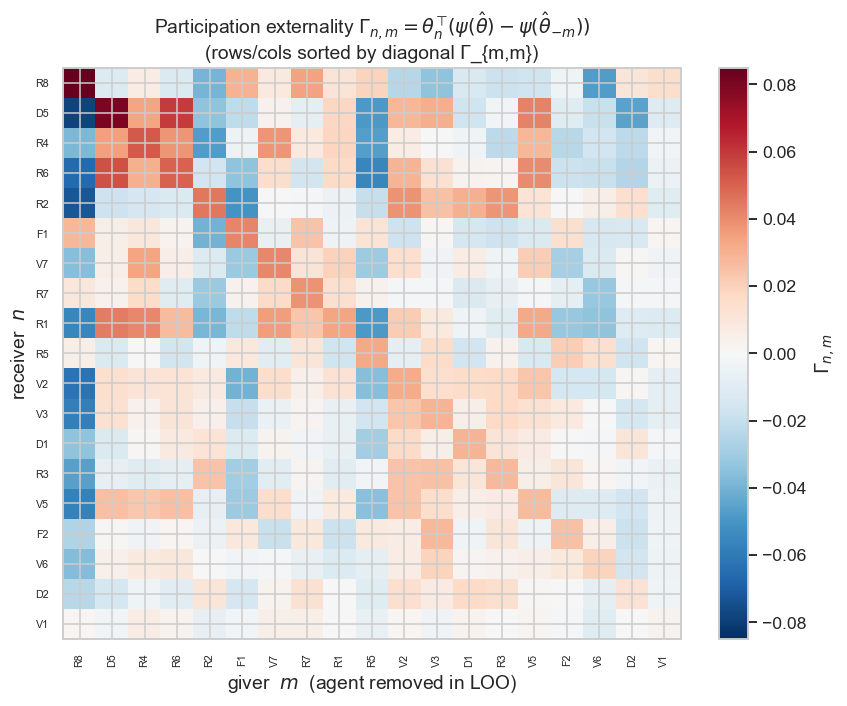

In [33]:
# ── §7.2 build the Γ matrix and visualize ────────────────────────────────
# Γ_{n,m} = θ_n^T (ψ(θ̂) − ψ(θ̂_{-m}))    shape (N, N)

psi_full = psi_rlhf_b1                                       # already computed in §6
delta_psi_m = psi_full[None, :] - psi_loo                    # (N, k)  for each m
Gamma = Theta @ delta_psi_m.T                                # (N, N)  rows=n, cols=m

# Sanity: diagonal = own benefit (should typically be ≥ 0 — including yourself
# helps your own welfare, since BTL with you in the pool fits your preferences better)
diag_pos_frac = (np.diag(Gamma) > 0).mean()
print(f"Γ_{{n,m}} matrix shape: {Gamma.shape}")
print(f"diagonal (own benefit Γ_{{m,m}}): mean = {np.diag(Gamma).mean():+.5f}, "
      f"fraction positive = {diag_pos_frac:.0%}")
print(f"off-diagonal (cross externalities): mean = "
      f"{(Gamma.sum() - np.diag(Gamma).sum()) / (N_AGENTS*(N_AGENTS-1)):+.5f}")
print(f"|Γ| range: [{np.abs(Gamma).min():.5f}, {np.abs(Gamma).max():.5f}]")

# Heatmap — rows = receivers n, columns = givers m
order = np.argsort(np.diag(Gamma))[::-1]    # sort agents by diagonal so heatmap is interpretable
G_ord = Gamma[np.ix_(order, order)]
labels_ord = agent_ids[order]

fig, ax = plt.subplots(figsize=(8, 6.6))
vmax = np.max(np.abs(Gamma))
im = ax.imshow(G_ord, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
plt.colorbar(im, ax=ax, label=r"$\Gamma_{n,m}$")
ax.set_xticks(range(N_AGENTS)); ax.set_xticklabels(labels_ord, rotation=90, fontsize=7)
ax.set_yticks(range(N_AGENTS)); ax.set_yticklabels(labels_ord, fontsize=7)
ax.set_xlabel("giver  $m$  (agent removed in LOO)")
ax.set_ylabel("receiver  $n$")
ax.set_title(r"Participation externality $\Gamma_{n,m} = \theta_n^\top(\psi(\hat\theta) - \psi(\hat\theta_{-m}))$"
             "\n(rows/cols sorted by diagonal Γ_{m,m})")
plt.tight_layout()
plt.show()


agents who impose the largest positive externalities on others:
personID  Γ_{m,m} own  Σ_n Γ_{n,m} (m's total impact)  off-diag impact  Σ_m Γ_{n,m} (n receives)  off-diag received
      V2      0.03152                         0.23555          0.20403                   0.00072           -0.03081
      R4      0.05233                         0.24329          0.19096                  -0.00175           -0.05408
      V5      0.02657                         0.21236          0.18579                  -0.00023           -0.02680
      V3      0.02896                         0.19428          0.16532                   0.00135           -0.02761
      R6      0.05029                         0.18557          0.13528                  -0.00090           -0.05119

agents who impose the largest negative externalities on others:
personID  Γ_{m,m} own  Σ_n Γ_{n,m} (m's total impact)  off-diag impact  Σ_m Γ_{n,m} (n receives)  off-diag received
      R8      0.08488                        -0.56212      

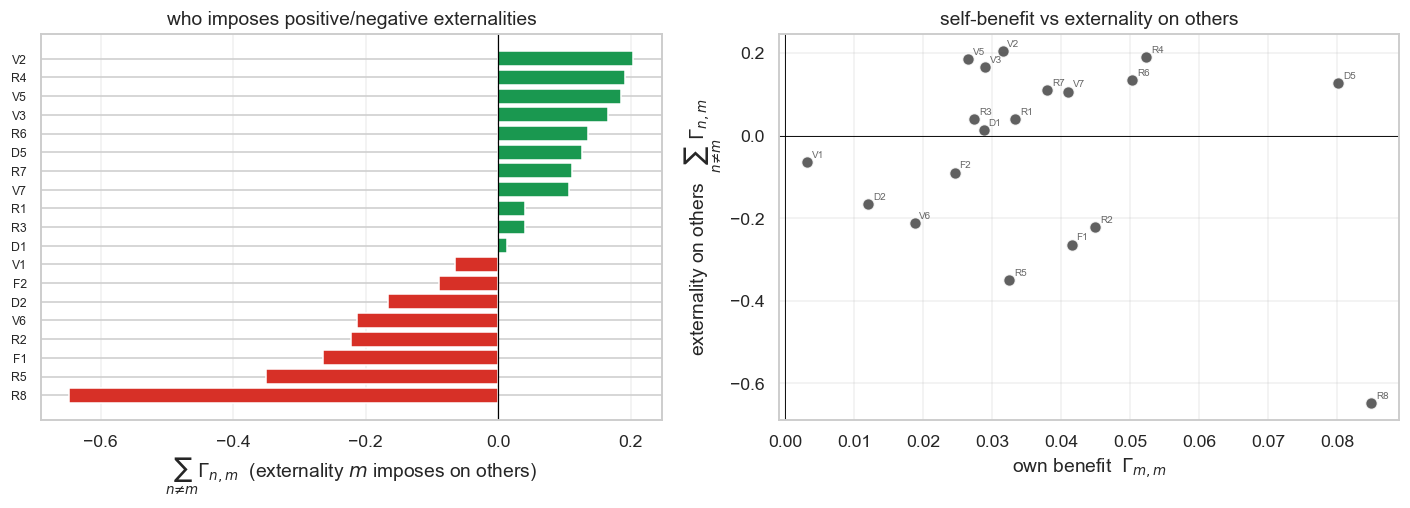


correlation(own benefit, externality on others) = -0.187
  (negative ⇒ agents who benefit most from being in the pool tend to hurt others)


In [34]:
# ── §7.3 headlines: who imposes / receives externalities ─────────────────
col_sum = Gamma.sum(axis=0)             # total externality m imposes on the pool (incl. self)
row_sum = Gamma.sum(axis=1)             # total externality n receives
diag    = np.diag(Gamma)
off_diag_col = col_sum - diag           # externality m imposes on OTHERS only
off_diag_row = row_sum - diag           # externality n receives from OTHERS only

summary = pd.DataFrame({
    "personID":           agent_ids,
    "Γ_{m,m} own":        diag,
    "Σ_n Γ_{n,m} (m's total impact)": col_sum,
    "off-diag impact":    off_diag_col,
    "Σ_m Γ_{n,m} (n receives)": row_sum,
    "off-diag received":  off_diag_row,
}).round(5)

print("agents who impose the largest positive externalities on others:")
print(summary.sort_values("off-diag impact", ascending=False).head(5).to_string(index=False))
print("\nagents who impose the largest negative externalities on others:")
print(summary.sort_values("off-diag impact").head(5).to_string(index=False))
print(f"\n(positive = m's inclusion *helps* others; negative = m's inclusion *hurts* others)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ord_imp = np.argsort(off_diag_col)
axes[0].barh(range(N_AGENTS), off_diag_col[ord_imp],
             color=["#1a9850" if v >= 0 else "#d73027" for v in off_diag_col[ord_imp]])
axes[0].set_yticks(range(N_AGENTS))
axes[0].set_yticklabels(np.array(agent_ids)[ord_imp], fontsize=8)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel(r"$\sum_{n \ne m}\Gamma_{n,m}$  (externality $m$ imposes on others)")
axes[0].set_title("who imposes positive/negative externalities")
axes[0].grid(True, axis="x", alpha=0.3)

axes[1].scatter(diag, off_diag_col, s=60, color="#444", alpha=0.85, edgecolor="white")
axes[1].axhline(0, color="black", lw=0.6); axes[1].axvline(0, color="black", lw=0.6)
axes[1].set_xlabel(r"own benefit  $\Gamma_{m,m}$")
axes[1].set_ylabel(r"externality on others  $\sum_{n \ne m}\Gamma_{n,m}$")
axes[1].set_title("self-benefit vs externality on others")
axes[1].grid(True, alpha=0.3)
for m, pid in enumerate(agent_ids):
    axes[1].annotate(pid, (diag[m], off_diag_col[m]), fontsize=6.5, alpha=0.7,
                     xytext=(3, 3), textcoords="offset points")

plt.tight_layout()
plt.show()

print(f"\ncorrelation(own benefit, externality on others) = "
      f"{np.corrcoef(diag, off_diag_col)[0,1]:+.3f}")
print("  (negative ⇒ agents who benefit most from being in the pool tend to hurt others)")


### 7.6 Group by KMeans clustering on $\theta_n$ (k=4)

The V/R/F/D prefixes are exogenous (stakeholder type). It's also useful to group agents by whose *preferences are similar* — if K-means on $\Theta$ finds 4 clusters, those clusters define preference-similar cohorts, and we can ask the same within-vs-across externality questions but with an endogenous grouping.

Cluster labels are sorted by cluster size descending (so C0 is the largest cluster). Diagonal of the within-cluster summary cell still excludes own benefit $\Gamma_{m,m}$.


KMeans clusters (k=4):  {'C0': 7, 'C1': 6, 'C2': 3, 'C3': 3}

cluster centers (mean θ_n in each cluster):
     size  access  income  poverty  last_donation  total_donation   dist
C0  0.535   1.460  -0.391    0.746         -0.007          -0.011 -0.017
C1  0.618   0.511  -0.289    0.091          0.086          -0.014 -0.799
C2  0.310   0.596  -1.553    0.215          0.028          -0.001 -0.227
C3 -0.741   0.868   0.188    0.870         -0.022          -0.024 -1.094

cluster vs prefix-group cross-tab:
prefix   D  F  R  V
cluster            
C0       2  0  3  2
C1       0  1  2  3
C2       1  0  1  1
C3       0  1  2  0


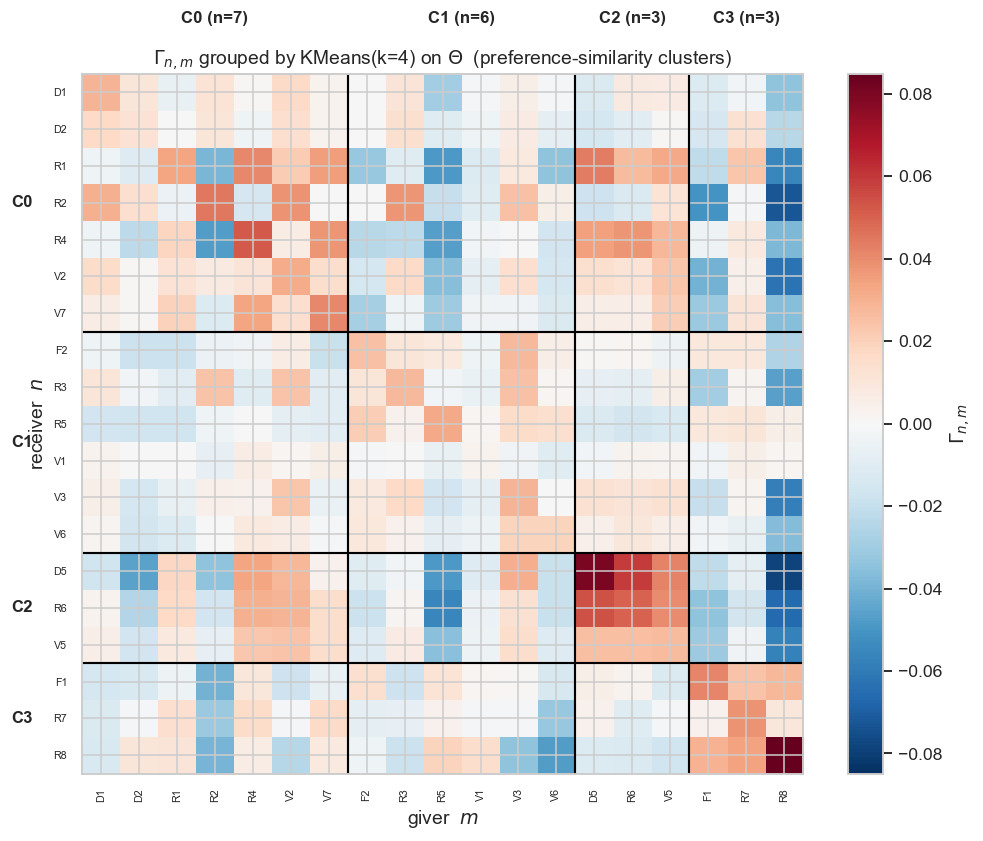

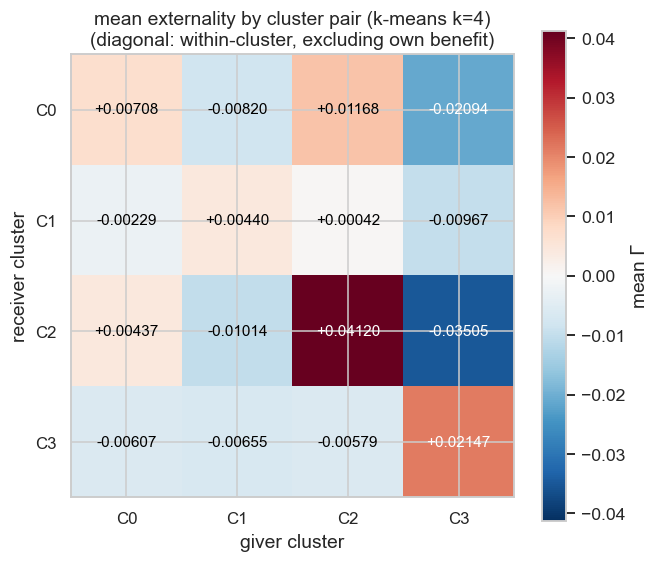


per-cluster mean Γ (rows=receiver, cols=giver):
         C0       C1       C2       C3
C0  0.00708 -0.00820  0.01168 -0.02094
C1 -0.00229  0.00440  0.00042 -0.00967
C2  0.00437 -0.01014  0.04120 -0.03505
C3 -0.00607 -0.00655 -0.00579  0.02147

WITHIN-cluster avg:  +0.01854
ACROSS-cluster avg:  -0.00735
diff (within − across): +0.02589

per-cluster totals:
   cluster   avg Γ from    avg Γ to
        C0     +0.00077    -0.00259
        C1     -0.00512    -0.00178
        C2     +0.01187    +0.00010
        C3     -0.01105    +0.00076

own-benefit Γ_{m,m} by cluster:
  C0 (n=7): mean = +0.03486, min = +0.01207, max = +0.05233
  C1 (n=6): mean = +0.02257, min = +0.00319, max = +0.03248
  C2 (n=3): mean = +0.05233, min = +0.02657, max = +0.08012
  C3 (n=3): mean = +0.05479, min = +0.03796, max = +0.08488


In [35]:
# ── §7.6 KMeans (k=4) clustering on Θ → externality grouping ─────────────
from sklearn.cluster import KMeans

K_CLUST = 4
km = KMeans(n_clusters=K_CLUST, n_init=20, random_state=0).fit(Theta)
raw_labels = km.labels_

# Relabel clusters in order of size (descending), so C0 = biggest
sizes = pd.Series(raw_labels).value_counts()
relabel = {old: new for new, old in enumerate(sizes.index)}
clusters = np.array([f"C{relabel[c]}" for c in raw_labels])
unique_clust = sorted(np.unique(clusters))
counts_c = {c: int((clusters == c).sum()) for c in unique_clust}
print(f"KMeans clusters (k={K_CLUST}):  {counts_c}")

# Exogenous V/R/F/D stakeholder prefix from personID (first char)
groups = np.array([pid[0] for pid in agent_ids])

# Print cluster centers + which prefix-groups land where (cross-tab)
print("\ncluster centers (mean θ_n in each cluster):")
centers = pd.DataFrame(
    [Theta[clusters == c].mean(axis=0) for c in unique_clust],
    index=unique_clust, columns=FEAT_COLS).round(3)
print(centers.to_string())

print("\ncluster vs prefix-group cross-tab:")
print(pd.crosstab(pd.Series(clusters, name="cluster"),
                  pd.Series(groups,   name="prefix")).to_string())

# ===== Heatmap, agents reordered by cluster =====
order_c = np.lexsort((agent_ids, clusters))
G_ord = Gamma[np.ix_(order_c, order_c)]
labels_ord = agent_ids[order_c]
clust_ord = clusters[order_c]
boundaries_c = [i for i in range(1, len(clust_ord)) if clust_ord[i] != clust_ord[i-1]]

fig, ax = plt.subplots(figsize=(9.2, 7.8))
vmax = np.max(np.abs(Gamma))
im = ax.imshow(G_ord, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
plt.colorbar(im, ax=ax, label=r"$\Gamma_{n,m}$")
ax.set_xticks(range(N_AGENTS)); ax.set_xticklabels(labels_ord, rotation=90, fontsize=7)
ax.set_yticks(range(N_AGENTS)); ax.set_yticklabels(labels_ord, fontsize=7)
ax.set_xlabel("giver  $m$"); ax.set_ylabel("receiver  $n$")
for b in boundaries_c:
    ax.axhline(b - 0.5, color="black", lw=1.4)
    ax.axvline(b - 0.5, color="black", lw=1.4)
for c in unique_clust:
    pos = np.where(clust_ord == c)[0]
    mid = (pos[0] + pos[-1]) / 2
    ax.annotate(f"{c} (n={counts_c[c]})", xy=(mid, -1.8),
                fontsize=11, fontweight="bold", ha="center", va="bottom",
                annotation_clip=False)
    ax.annotate(c, xy=(-1.8, mid),
                fontsize=11, fontweight="bold", ha="right", va="center",
                annotation_clip=False)
ax.set_title(r"$\Gamma_{n,m}$ grouped by KMeans(k=4) on $\Theta$"
             "  (preference-similarity clusters)")
plt.tight_layout()
plt.show()

# ===== Per-cluster summary =====
n_c = len(unique_clust)
G_summary_c = np.zeros((n_c, n_c))
for i, cn in enumerate(unique_clust):
    for j, cm in enumerate(unique_clust):
        block = Gamma[np.ix_(clusters == cn, clusters == cm)]
        if i == j:
            offdiag = block[~np.eye(block.shape[0], dtype=bool)]
            G_summary_c[i, j] = offdiag.mean() if offdiag.size > 0 else 0.0
        else:
            G_summary_c[i, j] = block.mean()

fig, ax = plt.subplots(figsize=(6.2, 5.4))
vmax_s = np.max(np.abs(G_summary_c))
im2 = ax.imshow(G_summary_c, cmap="RdBu_r", vmin=-vmax_s, vmax=vmax_s)
plt.colorbar(im2, ax=ax, label=r"mean $\Gamma$")
ax.set_xticks(range(n_c)); ax.set_xticklabels(unique_clust, fontsize=11)
ax.set_yticks(range(n_c)); ax.set_yticklabels(unique_clust, fontsize=11)
ax.set_xlabel("giver cluster"); ax.set_ylabel("receiver cluster")
ax.set_title("mean externality by cluster pair (k-means k=4)\n(diagonal: within-cluster, excluding own benefit)")
for i in range(n_c):
    for j in range(n_c):
        ax.text(j, i, f"{G_summary_c[i,j]:+.5f}",
                ha="center", va="center", fontsize=10,
                color="white" if abs(G_summary_c[i,j]) > 0.5*vmax_s else "black")
plt.tight_layout()
plt.show()

print("\nper-cluster mean Γ (rows=receiver, cols=giver):")
print(pd.DataFrame(G_summary_c, index=unique_clust, columns=unique_clust).round(5).to_string())

within_c = np.diag(G_summary_c)
off_mask_c = ~np.eye(n_c, dtype=bool)
print(f"\nWITHIN-cluster avg:  {within_c.mean():+.5f}")
print(f"ACROSS-cluster avg:  {G_summary_c[off_mask_c].mean():+.5f}")
print(f"diff (within − across): {within_c.mean() - G_summary_c[off_mask_c].mean():+.5f}")

# Per-cluster totals
print(f"\nper-cluster totals:")
print(f"  {'cluster':>8s}  {'avg Γ from':>11s}  {'avg Γ to':>10s}")
for j, cm in enumerate(unique_clust):
    print(f"  {cm:>8s}  {G_summary_c[:,j].mean():>+11.5f}  {G_summary_c[j,:].mean():>+10.5f}")

# Diagonal (own benefit) by cluster — useful comparison
own = np.diag(Gamma)
print(f"\nown-benefit Γ_{{m,m}} by cluster:")
for c in unique_clust:
    mask = clusters == c
    print(f"  {c} (n={mask.sum()}): mean = {own[mask].mean():+.5f}, "
          f"min = {own[mask].min():+.5f}, max = {own[mask].max():+.5f}")


### 7.7 Parameterized API for the main objects

Wrapping the primitives ($\psi$, $\psi^\star$, $W_n$, BTL fit, LOO BTL fit, $\Gamma_{n,m}$) into reusable functions so any caller can plug in their own $\hat\theta$, queries $\alpha$, agent pair $(n, m)$, deployment temperature $\beta$, and BTL regularization $C$.

Two layers:
- **Primitives** — take pre-computed $\hat\theta$ and queries; do no fitting.
- **From-data convenience wrappers** — handle BTL fitting (including LOO) from raw $(\alpha_{\rm train}, y_{\rm train}, \text{person\_id})$.


In [36]:
# ── §7.7 reusable API ─────────────────────────────────────────────────────
# Conventions: no factor of 2 anywhere (matches §1–§6).
# Notation:
#   theta_n      receiver's preference (k,)
#   theta_c      deployment policy (k,)
#   theta_hat    pooled BTL estimate (k,)
#   alpha_dep    deployment queries (M, k)  — usually = alpha_train
#   beta         deployment temperature
#   C            BTL L2 regularization (sklearn LogisticRegression convention)


# ============ PRIMITIVES (no fitting) ============

def psi_fn(theta_c, alpha_dep, beta=1.0):
    # Impact vector: psi(beta*theta_c) = E_z[ alpha_z * (sigma(beta * alpha_z^T theta_c) - 1/2) ]
    factor = sigmoid(beta * (alpha_dep @ theta_c)) - 0.5
    return (alpha_dep * factor[:, None]).mean(axis=0)


def psi_star_fn(theta_w, alpha_dep):
    # Welfare-optimal limit: psi^* = 1/2 * E_z[ alpha_z * sign(alpha_z^T theta_w) ]
    s = np.sign(alpha_dep @ theta_w)
    return 0.5 * (alpha_dep * s[:, None]).mean(axis=0)


def welfare_n_fn(theta_n, theta_c, alpha_dep, beta=1.0):
    # W_n(theta_c) = theta_n^T psi(theta_c)
    return float(theta_n @ psi_fn(theta_c, alpha_dep, beta))


def welfare_social_fn(theta_bar, theta_c, alpha_dep, beta=1.0):
    # W(theta_c) = theta_bar^T psi(theta_c)  with theta_bar = sum_n w_n theta_n
    return float(theta_bar @ psi_fn(theta_c, alpha_dep, beta))


def alignment_externality_fn(theta_n, theta_hat, theta_hat_minus_m, alpha_dep, beta=1.0):
    # Gamma_{n,m} = theta_n^T (psi(theta_hat) - psi(theta_hat_{-m}))
    delta_psi = psi_fn(theta_hat, alpha_dep, beta) - psi_fn(theta_hat_minus_m, alpha_dep, beta)
    return float(theta_n @ delta_psi)


# ============ BTL FITTING ============

def fit_btl_fn(alpha, y, C=1.0):
    # Pooled BTL: returns theta_hat
    lr = LogisticRegression(fit_intercept=False, C=C, solver="lbfgs", max_iter=2000, tol=1e-8)
    lr.fit(alpha, y)
    return lr.coef_.ravel()


def fit_btl_loo_fn(alpha, y, ids, m_id, C=1.0):
    # LOO BTL: pooled BTL fit on (alpha, y) with rows where ids == m_id removed.
    keep = (np.asarray(ids) != m_id)
    return fit_btl_fn(np.asarray(alpha)[keep], np.asarray(y)[keep], C=C)


# ============ FROM-DATA CONVENIENCE WRAPPERS ============

def alignment_externality_from_data(
    theta_n, m_id,
    alpha_train, y_train, person_id_train,
    alpha_dep=None, C=1.0, beta=1.0,
    theta_hat=None,                       # optional cached pooled estimate
):
    # Computes Gamma_{n,m} from raw data: fits theta_hat (if not cached) and theta_hat_{-m},
    # then evaluates Gamma against alpha_dep at deployment temperature beta.
    if alpha_dep is None:
        alpha_dep = alpha_train
    if theta_hat is None:
        theta_hat = fit_btl_fn(alpha_train, y_train, C=C)
    theta_hat_minus_m = fit_btl_loo_fn(alpha_train, y_train, person_id_train, m_id, C=C)
    return alignment_externality_fn(theta_n, theta_hat, theta_hat_minus_m, alpha_dep, beta)


def gamma_matrix_fn(
    Theta_arr, agent_ids_arr,
    alpha_train, y_train, person_id_train,
    alpha_dep=None, C=1.0, beta=1.0,
):
    # Builds the full N x N alignment-externality matrix Gamma_{n,m}.
    # Returns (Gamma, theta_hat, theta_loo) — theta_loo[m] = theta_hat_{-m}.
    if alpha_dep is None:
        alpha_dep = alpha_train
    N_loc, K = Theta_arr.shape
    theta_hat = fit_btl_fn(alpha_train, y_train, C=C)
    theta_loo = np.zeros((N_loc, K))
    for m in range(N_loc):
        theta_loo[m] = fit_btl_loo_fn(alpha_train, y_train, person_id_train, agent_ids_arr[m], C=C)
    psi_full = psi_fn(theta_hat, alpha_dep, beta)
    psi_loo  = np.array([psi_fn(theta_loo[m], alpha_dep, beta) for m in range(N_loc)])
    G = Theta_arr @ (psi_full[None, :] - psi_loo).T
    return G, theta_hat, theta_loo


# ============ DEMO: reproduces §7.2 numbers ============
print("Demo: rebuild key §7 quantities from the API")

# (1) Pooled fit + ψ
theta_hat_demo = fit_btl_fn(alpha_train, y_train, C=BTL_C)
print(f"  ||theta_hat||           = {np.linalg.norm(theta_hat_demo):.4f}    "
      f"(matches theta_rlhf? {np.allclose(theta_hat_demo, theta_rlhf)})")

# (2) Single Γ_{n,m} for, say, n = R5, m = R8 (the §7.3 outlier giver)
n_id, m_id = "R5", "R8"
n_idx = list(agent_ids).index(n_id)
gamma_n_m = alignment_externality_from_data(
    theta_n=Theta[n_idx], m_id=m_id,
    alpha_train=alpha_train, y_train=y_train, person_id_train=person_id,
    C=BTL_C, beta=1.0, theta_hat=theta_hat_demo,
)
m_idx = list(agent_ids).index(m_id)
print(f"  Gamma[{n_id} ← {m_id}] (API)   = {gamma_n_m:+.6f}")
print(f"  Gamma[{n_id} ← {m_id}] (§7 mat) = {Gamma[n_idx, m_idx]:+.6f}    "
      f"(agree to {abs(gamma_n_m - Gamma[n_idx, m_idx]):.2e})")

# (3) Full Γ matrix via API → should match the §7 matrix
G_api, _, _ = gamma_matrix_fn(
    Theta, agent_ids,
    alpha_train, y_train, person_id,
    C=BTL_C, beta=1.0,
)
print(f"  ||Gamma_API - Gamma_§7|| (max abs) = {np.abs(G_api - Gamma).max():.2e}")

# (4) Welfare-optimal psi*
psi_star_demo = psi_star_fn(theta_bar, alpha_train)
print(f"  ||psi^*|| (API)         = {np.linalg.norm(psi_star_demo):.4f}    "
      f"(matches psi_star? {np.allclose(psi_star_demo, psi_star)})")

# (5) Try a nonstandard call: deployment β=10 instead of β=1
gamma_b10 = alignment_externality_from_data(
    theta_n=Theta[n_idx], m_id=m_id,
    alpha_train=alpha_train, y_train=y_train, person_id_train=person_id,
    C=BTL_C, beta=10.0, theta_hat=theta_hat_demo,
)
print(f"  Gamma[{n_id} ← {m_id}] at beta=10 (deterministic-ish) = {gamma_b10:+.6f}")


Demo: rebuild key §7 quantities from the API
  ||theta_hat||           = 0.8362    (matches theta_rlhf? True)
  Gamma[R5 ← R8] (API)   = +0.004738
  Gamma[R5 ← R8] (§7 mat) = +0.004738    (agree to 0.00e+00)
  ||Gamma_API - Gamma_§7|| (max abs) = 0.00e+00
  ||psi^*|| (API)         = 3.3262    (matches psi_star? True)
  Gamma[R5 ← R8] at beta=10 (deterministic-ish) = +0.018578


---

**§7 checkpoint.** Verify:

- LOO refits succeed for all $N$ agents and $\|\hat\theta_{-m} - \hat\theta\|$ is small relative to $\|\hat\theta\|$ (each agent contributes ~$1/N$ of the data).
- $\Gamma_{n,m}$ matrix matches the direct welfare computation `welfare_per_agent(θ̂) − welfare_per_agent(θ̂_{-m})` to machine precision.
- Diagonal $\Gamma_{m,m}$ is mostly positive — including yourself in the pool typically helps your own welfare.
- The off-diagonal column sum identifies agents who systematically push the policy in directions that help/hurt others.
- The scatter (own benefit vs externality on others) shows whether the "tyranny of the majority" pattern holds: do agents whose preferences match the population mean help others, or do agents who deviate most reap the largest own-benefit at others' cost?

Once confirmed, §8 is a final summary tying §1–§7 together.


## §8. Toy 2-feature illustration

A simple 2-D picture to make $\Psi$ visible. Setup:

- $k = 2$ features.
- A small fixed set of queries $\{\alpha_z\}_{z=1}^Z$ on the unit circle (so we can see the polytope shape clearly — finite query sets give a $\Psi$ that's a polygon with up to $2Z$ vertices).
- Three users with hand-picked preferences $\theta_A, \theta_B, \theta_C$ chosen to span the plane.
- For each user, the **ideal impact** $\psi_n^\star = \arg\max_{\psi\in\Psi}\theta_n^\top\psi = \tfrac12\,\mathbb E_z[\alpha_z\,\mathrm{sign}(\alpha_z^\top\theta_n)]$ — sits on the boundary of $\Psi$ in the direction picked out by the user's preference.
- The **utilitarian preference** $\bar\theta = \tfrac{1}{3}(\theta_A+\theta_B+\theta_C)$ and its corresponding $\psi^\star_{\rm util} = \arg\max_\psi \bar\theta^\top\psi$.

Each user's $\psi_n^\star$ is a different vertex of the polytope. RLHF picks one $\psi$ — the gap between $\psi_n^\star$ and that one is exactly the per-user welfare loss we computed in §6.


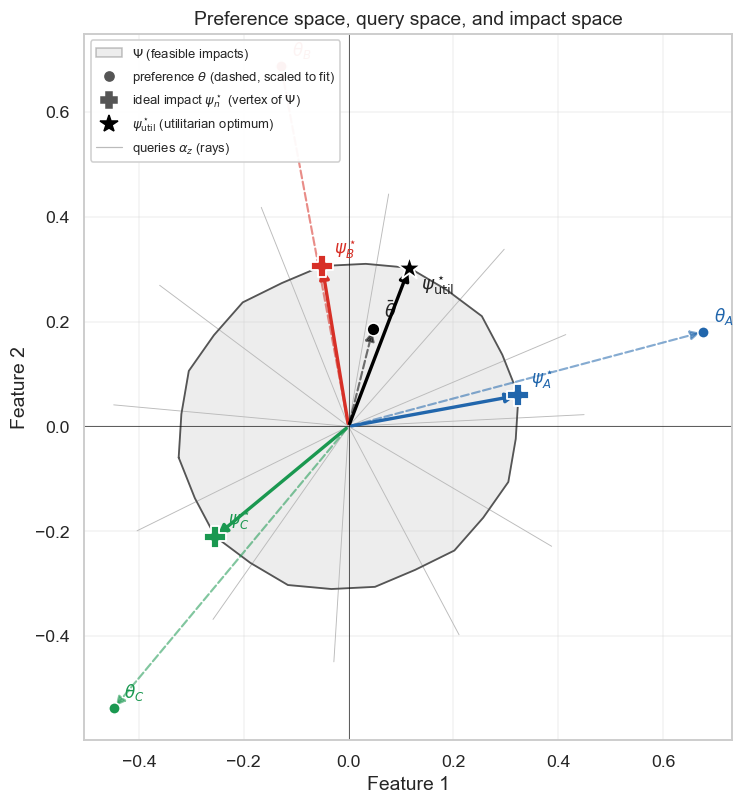

user preferences:
  theta_A = [1.5 0.4],  ||theta|| = 1.552
  theta_B = [-0.3  1.6],  ||theta|| = 1.628
  theta_C = [-1.  -1.2],  ||theta|| = 1.562
  theta_bar = [0.067 0.267],  ||theta_bar|| = 0.275

ideal impacts (each on boundary of Psi):
  psi*_A    = [0.3242 0.0593]
  psi*_B    = [-0.0504  0.3061]
  psi*_C    = [-0.2543 -0.2104]
  psi*_util  = [0.1158 0.3026]

welfare W_n at each candidate psi (rows: candidate; cols: user A,B,C, social):
                W_A       W_B       W_C       W_social
  psi*_A        +0.5100  -0.0023  -0.3954  +0.0374
  psi*_B        +0.0468  +0.5048  -0.3168  +0.0783
  psi*_C        -0.4656  -0.2603  +0.5068  -0.0731
  psi*_util     +0.2947  +0.4494  -0.4789  +0.0884

Each user's own psi*_n maxes their own column; psi*_util maxes the social column.


In [41]:
# ── §8 toy 2D illustration ───────────────────────────────────────────────
from scipy.spatial import ConvexHull

# Finite query set on the unit circle (12 points, asymmetric for an interesting polygon)
phi_q = np.array([0.05, 0.4, 0.85, 1.4, 1.95, 2.5, 3.05, 3.6, 4.1, 4.65, 5.2, 5.75])
alpha_toy = np.column_stack([np.cos(phi_q), np.sin(phi_q)])    # (Z, 2)

# Three user preferences (spans the plane)
theta_users = np.array([
    [ 1.5,  0.4],     # user A
    [-0.3,  1.6],     # user B
    [-1.0, -1.2],     # user C
])
user_labels = ["A", "B", "C"]
user_colors = ["#2166ac", "#d73027", "#1a9850"]

theta_bar_toy = theta_users.mean(axis=0)

# Support point of Psi in direction theta:  0.5 * E[ alpha * sign(alpha^T theta) ]
def psi_lim_2d(theta):
    s = np.sign(alpha_toy @ theta)
    return 0.5 * (alpha_toy * s[:, None]).mean(axis=0)

# Trace boundary of Ψ by sweeping θ over the unit circle, then take convex hull
sweep = np.linspace(0, 2 * np.pi, 720)
support_pts = np.array([psi_lim_2d(np.array([np.cos(p), np.sin(p)])) for p in sweep])
hull = ConvexHull(support_pts)
poly = support_pts[hull.vertices]

# Per-user ideal impacts and utilitarian-optimal impact
psi_users = np.array([psi_lim_2d(t) for t in theta_users])      # (3, 2)
psi_util  = psi_lim_2d(theta_bar_toy)

# Plot
fig, ax = plt.subplots(figsize=(7.5, 7.5))

# (1) Ψ polytope
ax.fill(np.append(poly[:, 0], poly[0, 0]),
        np.append(poly[:, 1], poly[0, 1]),
        color="#cccccc", alpha=0.35)
ax.plot(np.append(poly[:, 0], poly[0, 0]),
        np.append(poly[:, 1], poly[0, 1]),
        color="#555", lw=1.2)

# (2) Query vectors α as light grey rays (context)
for a in alpha_toy:
    ax.plot([0, 0.45 * a[0]], [0, 0.45 * a[1]], color="#bbbbbb", lw=0.6, zorder=1)

# (3) Per-user preference arrows (dashed) and ideal-impact arrows (solid, into Ψ)
for n in range(3):
    th = theta_users[n] / max(1.0, np.linalg.norm(theta_users[n])) * 0.7   # scale for plotting
    ax.annotate("", xy=th, xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=user_colors[n], lw=1.4,
                                alpha=0.55, ls="--"))
    ax.scatter(*th, s=55, color=user_colors[n], marker="o",
               edgecolor="white", linewidth=1, zorder=5)
    ax.annotate(rf"$\theta_{user_labels[n]}$", xy=th, fontsize=11,
                color=user_colors[n], fontweight="bold",
                xytext=(7, 7), textcoords="offset points")

    # Ideal impact ψ_n*
    ax.annotate("", xy=psi_users[n], xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=user_colors[n], lw=2.2))
    ax.scatter(*psi_users[n], s=210, color=user_colors[n], marker="P",
               edgecolor="white", linewidth=1.2, zorder=6)
    ax.annotate(rf"$\psi^\star_{user_labels[n]}$", xy=psi_users[n], fontsize=11,
                color=user_colors[n], fontweight="bold",
                xytext=(8, 8), textcoords="offset points")

# (4) Utilitarian θ̄ and ψ*_util
th_bar_plot = theta_bar_toy / max(1.0, np.linalg.norm(theta_bar_toy)) * 0.7
ax.annotate("", xy=th_bar_plot, xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color="black", lw=1.4, alpha=0.55, ls="--"))
ax.scatter(*th_bar_plot, s=70, color="black", marker="o",
           edgecolor="white", linewidth=1, zorder=5)
ax.annotate(r"$\bar\theta$", xy=th_bar_plot, fontsize=12, fontweight="bold",
            xytext=(7, 7), textcoords="offset points")

ax.annotate("", xy=psi_util, xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color="black", lw=2.2))
ax.scatter(*psi_util, s=260, color="black", marker="*",
           edgecolor="white", linewidth=1.2, zorder=6)
ax.annotate(r"$\psi^\star_{\rm util}$", xy=psi_util, fontsize=12, fontweight="bold",
            xytext=(8, -14), textcoords="offset points")

# Axes / legend
ax.axhline(0, color="black", lw=0.4); ax.axvline(0, color="black", lw=0.4)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2") 
ax.set_title("Preference space, query space, and impact space")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)

from matplotlib.lines import Line2D
legend_handles = [
    plt.Rectangle((0,0),1,1, facecolor="#cccccc", alpha=0.35, edgecolor="#555",
                  label=r"$\Psi$ (feasible impacts)"),
    Line2D([0],[0], color="#555", lw=0, marker="o", markerfacecolor="#555",
           markersize=6, label=r"preference $\theta$ (dashed, scaled to fit)"),
    Line2D([0],[0], color="#555", lw=0, marker="P", markerfacecolor="#555",
           markersize=10, label=r"ideal impact $\psi^\star_n$ (vertex of $\Psi$)"),
    Line2D([0],[0], color="black", lw=0, marker="*", markerfacecolor="black",
           markersize=12, label=r"$\psi^\star_{\rm util}$ (utilitarian optimum)"),
    Line2D([0],[0], color="#bbbbbb", lw=0.8, label=r"queries $\alpha_z$ (rays)"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=8.5, framealpha=0.95)

plt.tight_layout()
plt.show()

# Numerical summary — show that each ψ*_n maxes its own user's welfare,
# and ψ*_util maxes social welfare
print("user preferences:")
for n, lab in enumerate(user_labels):
    print(f"  theta_{lab} = {theta_users[n].round(3)},  ||theta|| = {np.linalg.norm(theta_users[n]):.3f}")
print(f"  theta_bar = {theta_bar_toy.round(3)},  ||theta_bar|| = {np.linalg.norm(theta_bar_toy):.3f}")
print()
print("ideal impacts (each on boundary of Psi):")
for n, lab in enumerate(user_labels):
    print(f"  psi*_{lab}    = {psi_users[n].round(4)}")
print(f"  psi*_util  = {psi_util.round(4)}")
print()
print("welfare W_n at each candidate psi (rows: candidate; cols: user A,B,C, social):")
candidates = {"psi*_A": psi_users[0], "psi*_B": psi_users[1], "psi*_C": psi_users[2], "psi*_util": psi_util}
header = f"  {'':12s}" + "".join(f"  W_{l}     " for l in user_labels) + "  W_social"
print(header)
for cand_name, p in candidates.items():
    Wn = theta_users @ p
    Wsoc = theta_bar_toy @ p
    print(f"  {cand_name:12s}" + "".join(f"  {w:+.4f}" for w in Wn) + f"  {Wsoc:+.4f}")
print()
print("Each user's own psi*_n maxes their own column; psi*_util maxes the social column.")


### 8.1 The duality: preference-space sectors $\leftrightarrow$ impact-space vertices

Side-by-side view making explicit why $\Psi$ has $2Z = 24$ vertices.

**Left (preference space).** The 12 queries $\alpha_z$ each define a line $L_z = \{\theta : \alpha_z^\top\theta = 0\}$ through the origin. These 12 lines carve $\mathbb{R}^2$ into 24 angular sectors. Within any sector the *sign pattern* $\sigma(\theta) = (\mathrm{sign}(\alpha_z^\top\theta))_z$ is constant — only as $\theta$ crosses some $L_z$ does one component of $\sigma$ flip.

**Right (impact space).** Each sector corresponds to one vertex of $\Psi$ via $\psi_{\rm vertex} = \tfrac{1}{2Z}\sum_z\sigma_z\alpha_z$. Colors match: same color on the left = same sector = same sign pattern = same vertex on the right.

Each user's $\theta_n$ falls into one sector → maps to that sector's vertex. That vertex is $\psi_n^\star$.


queries Z              = 12
crossings on circle    = 24  (= 2Z)
distinct sign patterns = 24
polygon vertices       = 24


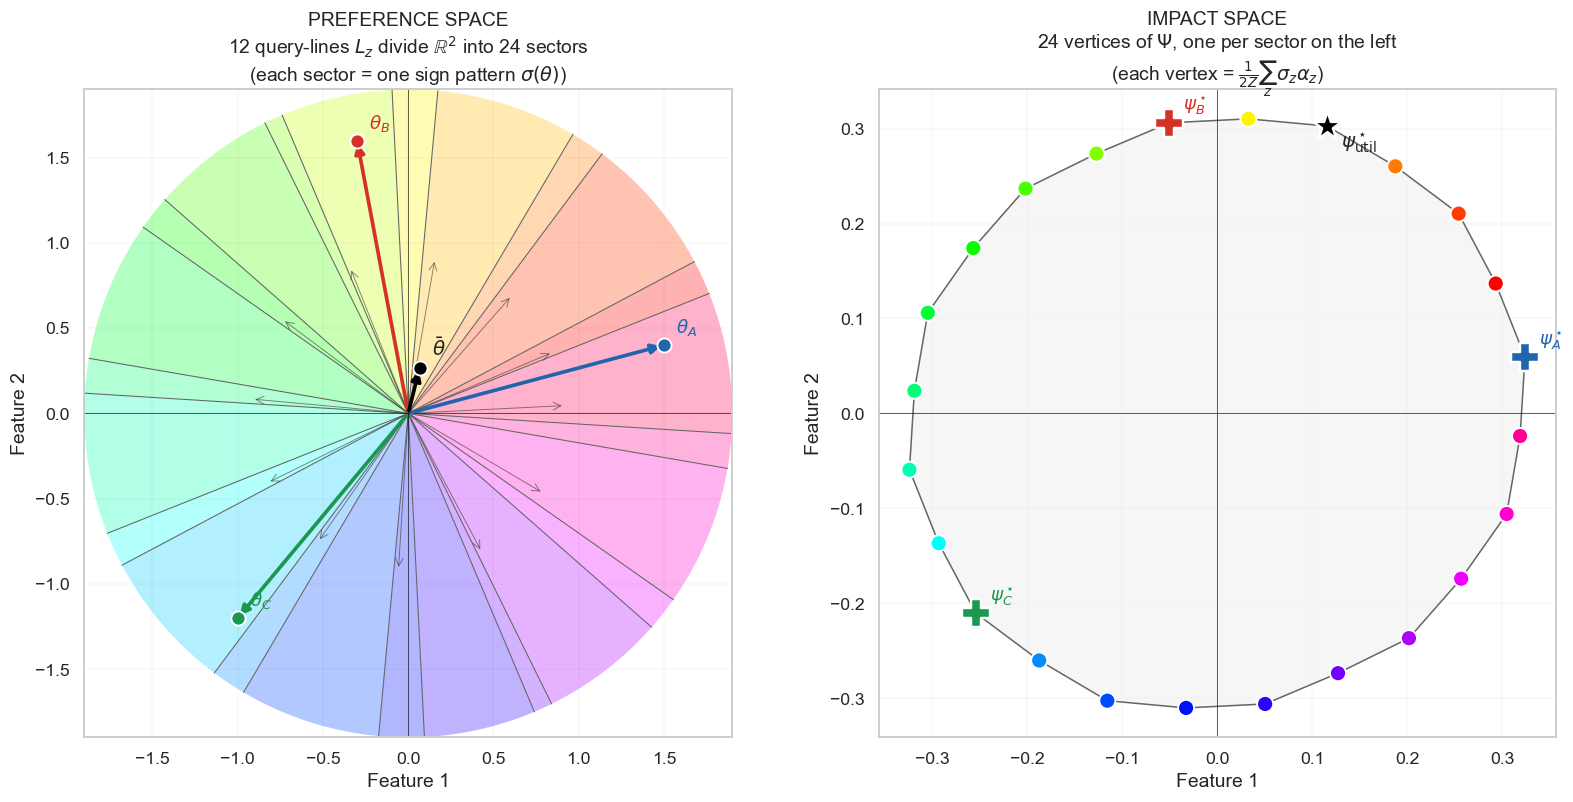


user → sector → vertex mapping:
  user A (theta=[1.5 0.4]): sector #23, sign pattern σ = (1, 1, 1, 1, -1, -1, -1, -1, -1, -1, 1, 1)
     → ψ*_A = [0.3242 0.0593]
  user B (theta=[-0.3  1.6]): sector # 5, sign pattern σ = (-1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1)
     → ψ*_B = [-0.0504  0.3061]
  user C (theta=[-1.  -1.2]): sector #13, sign pattern σ = (-1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, -1)
     → ψ*_C = [-0.2543 -0.2104]
  utilitarian (theta_bar=[0.07 0.27]): sector # 3, σ = (1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1)
     → ψ*_util = [0.1158 0.3026]


In [38]:
# ── §8.1 preference-space sectors ↔ impact-space vertices ─────────────────
from matplotlib import cm

# (Reuse the toy queries / users from §8)
Z = len(phi_q)

# 24 crossing angles where some L_z is crossed by the unit circle
crossing_angles = np.sort(np.concatenate([
    (phi_q + np.pi/2) % (2*np.pi),
    (phi_q - np.pi/2) % (2*np.pi),
]))

# Sector i = (crossing_angles[i], crossing_angles[(i+1) % 24]); pick midpoint as representative
def sector_midpoint(i):
    a_lo = crossing_angles[i]
    a_hi = crossing_angles[(i+1) % len(crossing_angles)]
    if a_hi < a_lo:                       # wraparound
        a_hi = a_hi + 2*np.pi
    return (a_lo + a_hi) / 2

# Build sector → vertex mapping
sector_sigmas = []
sector_vertices = []
for i in range(len(crossing_angles)):
    mid = sector_midpoint(i)
    th_mid = np.array([np.cos(mid), np.sin(mid)])
    s = np.sign(alpha_toy @ th_mid)
    sector_sigmas.append(s)
    sector_vertices.append(0.5 * (alpha_toy * s[:, None]).mean(axis=0))
sector_sigmas = np.array(sector_sigmas)
sector_vertices = np.array(sector_vertices)

print(f"queries Z              = {Z}")
print(f"crossings on circle    = {len(crossing_angles)}  (= 2Z)")
print(f"distinct sign patterns = {len({tuple(s) for s in sector_sigmas})}")
print(f"polygon vertices       = {len(sector_vertices)}")

# Find which sector each user (and θ̄) falls in
def find_sector(theta):
    s = np.sign(alpha_toy @ theta)
    for i, ss in enumerate(sector_sigmas):
        if np.array_equal(s, ss):
            return i
    return 0

sector_users = [find_sector(t) for t in theta_users]
sector_util  = find_sector(theta_bar_toy)

# Distinct color per sector
sector_colors = cm.hsv(np.linspace(0, 1, len(crossing_angles), endpoint=False))

# ── Plot ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7.2))

# ===== LEFT: preference space =====
R_pref = 1.9

# Color each sector as a wedge
for i in range(len(crossing_angles)):
    a_lo = crossing_angles[i]
    a_hi = crossing_angles[(i+1) % len(crossing_angles)]
    if a_hi < a_lo:
        a_hi = a_hi + 2*np.pi
    angles_fill = np.linspace(a_lo, a_hi, 24)
    pts = R_pref * np.column_stack([np.cos(angles_fill), np.sin(angles_fill)])
    poly = np.vstack([[0, 0], pts, [0, 0]])
    ax1.fill(poly[:, 0], poly[:, 1], color=sector_colors[i], alpha=0.30, edgecolor="none")

# Draw the 12 query lines L_z (through origin, perpendicular to α_z)
for a in alpha_toy:
    d = np.array([-a[1], a[0]])
    ax1.plot([-R_pref * d[0], R_pref * d[0]],
             [-R_pref * d[1], R_pref * d[1]],
             color="#666", lw=0.7, zorder=2)

# Query vectors α_z as small grey arrows
for a in alpha_toy:
    ax1.annotate("", xy=0.92 * a, xytext=(0, 0),
                 arrowprops=dict(arrowstyle="->", color="#333", lw=0.6, alpha=0.6))

# User preferences
for n in range(3):
    ax1.annotate("", xy=theta_users[n], xytext=(0, 0),
                 arrowprops=dict(arrowstyle="-|>", color=user_colors[n], lw=2.4))
    ax1.scatter(*theta_users[n], s=85, color=user_colors[n], marker="o",
                edgecolor="white", linewidth=1.2, zorder=6)
    ax1.annotate(rf"$\theta_{user_labels[n]}$", xy=theta_users[n],
                 xytext=(8, 8), textcoords="offset points",
                 fontsize=12, color=user_colors[n], fontweight="bold")

# θ̄
ax1.annotate("", xy=theta_bar_toy, xytext=(0, 0),
             arrowprops=dict(arrowstyle="-|>", color="black", lw=2.4))
ax1.scatter(*theta_bar_toy, s=85, color="black", marker="o",
            edgecolor="white", linewidth=1.2, zorder=6)
ax1.annotate(r"$\bar\theta$", xy=theta_bar_toy,
             xytext=(8, 8), textcoords="offset points",
             fontsize=13, fontweight="bold")

ax1.set_xlim(-R_pref, R_pref); ax1.set_ylim(-R_pref, R_pref)
ax1.set_aspect("equal")
ax1.axhline(0, color="black", lw=0.4); ax1.axvline(0, color="black", lw=0.4)
ax1.grid(True, alpha=0.15)
ax1.set_title("PREFERENCE SPACE\n12 query-lines $L_z$ divide $\\mathbb{R}^2$ into 24 sectors\n"
              "(each sector = one sign pattern $\\sigma(\\theta)$)")
ax1.set_xlabel("Feature 1"); ax1.set_ylabel("Feature 2")

# ===== RIGHT: impact space =====
# Polygon edges + fill (color the edges grey, fill light)
poly_closed = np.vstack([sector_vertices, sector_vertices[0]])
ax2.fill(sector_vertices[:, 0], sector_vertices[:, 1], color="#eeeeee", alpha=0.5)
ax2.plot(poly_closed[:, 0], poly_closed[:, 1], color="#666", lw=1.0)

# Each vertex colored to match its sector
ax2.scatter(sector_vertices[:, 0], sector_vertices[:, 1],
            s=110, c=sector_colors, edgecolor="white", linewidth=1.2, zorder=4)

# User ψ*_n at the matching sector vertex (using sector color circle + bigger user-color marker)
for n, lab in enumerate(user_labels):
    v = sector_vertices[sector_users[n]]
    ax2.scatter(*v, s=320, color=user_colors[n], marker="P",
                edgecolor="white", linewidth=1.6, zorder=7)
    ax2.annotate(rf"$\psi^\star_{lab}$", xy=v,
                 xytext=(9, 9), textcoords="offset points",
                 fontsize=12, color=user_colors[n], fontweight="bold")

v_util = sector_vertices[sector_util]
ax2.scatter(*v_util, s=380, color="black", marker="*",
            edgecolor="white", linewidth=1.6, zorder=7)
ax2.annotate(r"$\psi^\star_{\rm util}$", xy=v_util,
             xytext=(9, -14), textcoords="offset points",
             fontsize=13, fontweight="bold")

ax2.axhline(0, color="black", lw=0.4); ax2.axvline(0, color="black", lw=0.4)
ax2.grid(True, alpha=0.15)
ax2.set_aspect("equal")
ax2.set_title("IMPACT SPACE\n24 vertices of $\\Psi$, one per sector on the left\n"
              r"(each vertex = $\frac{1}{2Z}\sum_z \sigma_z\alpha_z$)")
ax2.set_xlabel("Feature 1"); ax2.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

# Show the explicit sector → vertex mapping for the highlighted users
print()
print("user → sector → vertex mapping:")
for n, lab in enumerate(user_labels):
    sig = sector_sigmas[sector_users[n]]
    print(f"  user {lab} (theta={theta_users[n].round(2)}): "
          f"sector #{sector_users[n]:2d}, sign pattern σ = {tuple(int(x) for x in sig)}")
    print(f"     → ψ*_{lab} = {sector_vertices[sector_users[n]].round(4)}")
sig_u = sector_sigmas[sector_util]
print(f"  utilitarian (theta_bar={theta_bar_toy.round(2)}): "
      f"sector #{sector_util:2d}, σ = {tuple(int(x) for x in sig_u)}")
print(f"     → ψ*_util = {sector_vertices[sector_util].round(4)}")


## §9. Strategyproof alignment

**Theorem (random dictatorship characterization).** Under $\dim(\bar\Psi)\ge 2$, every strategyproof + unanimous mechanism is a random dictatorship on generic profiles:

$$\mu_\lambda(\theta) = \sum_{n=1}^N \lambda_n\,\delta(\psi_n^\star), \qquad \psi_n^\star = \arg\max_{\psi\in\bar\Psi}\theta_n^\top\psi = \tfrac12\mathbb E_z[\alpha_z\,\mathrm{sign}(\alpha_z^\top\theta_n)].$$

**Theorem (single-model implementation).** Any strategyproof mechanism is realizable by a single parameter

$$\theta^{\rm sp}_\lambda = \psi^{-1}\!\left(\sum_n \lambda_n \psi_n^\star\right).$$

So we don't need to actually train one LoRA per user and randomly route — we can fold the same expected impact into a single $\theta$ by inverting $\psi$.

**Distortion.** $\mathrm{Dist}(\mu_\lambda;\theta) = \dfrac{W^\star(\theta)}{\bar\theta^\top \psi^{\rm sp}_\lambda} = \dfrac{\bar\theta^\top\psi^\star}{\bar\theta^\top\psi^{\rm sp}_\lambda}$.

The strategyproof feasible set is $\Psi^{\rm sp} = \mathrm{Hull}(\{\psi_n^\star\}_{n=1}^N) \subseteq \Psi$, so distortion is bounded only when $\Psi^{\rm sp}$ contains $\psi^\star$ — generically it doesn't (Prop "unbounded distortion").

**$\lambda$ choices to compare.**

| label | $\lambda$ | rationale |
|---|---|---|
| **eg** | $\lambda_n = 1/N$ | egalitarian random dictatorship |
| **w** | $\lambda = w$ | welfare-weighted (same as eg here since $w$ uniform) |
| **dict-θ̄** | $\lambda$ degenerate on $\arg\max_n \bar\theta^\top\psi_n^\star$ | maximizes social welfare within $\Psi^{\rm sp}$ |
| **dict-ψ\*** | $\lambda$ degenerate on $\arg\max_n \psi_n^{\star\top}\psi^\star$ | projects $\psi^\star$ onto $\Psi^{\rm sp}$ |

**Strategyproof externality** (Eq. for $\Gamma^{\rm sp}$):

$$\Gamma^{\rm sp}_{n,m} = \lambda_n\,\theta_m^\top\bigl(\psi_n^\star - \psi^{\rm sp}_{\lambda,-n}\bigr), \qquad \psi^{\rm sp}_{\lambda,-n} = \tfrac{1}{1-\lambda_n}\sum_{i\ne n}\lambda_i\psi_i^\star.$$


In [39]:
# ── §9.1 per-agent ψ*_n + four λ choices + distortion ────────────────────
# ψ*_n = argmax_{ψ∈Ψ} θ_n^T ψ = (1/2) E[α sign(α^T θ_n)]    (closed form)

# Per-agent ideal impacts
psi_n_star = np.array([psi_star_fn(Theta[n], alpha_train) for n in range(N_AGENTS)])  # (N, k)
print(f"per-agent ψ*_n shape: {psi_n_star.shape}")
print(f"  ||ψ*_n|| range:    [{np.linalg.norm(psi_n_star, axis=1).min():.4f}, "
      f"{np.linalg.norm(psi_n_star, axis=1).max():.4f}]")

# Welfare-optimal psi^* (already computed in §5; re-derive for clarity)
psi_star_util = psi_star_fn(theta_bar, alpha_train)
W_star_val = float(theta_bar @ psi_star_util)
print(f"  W* = θ̄^T ψ*       = {W_star_val:.4f}")

# Welfare each ψ*_n delivers if used as a dictatorship
W_n_dict = Theta @ psi_n_star.T            # (N, N): row n, col m gives W_n at ψ*_m... unused later
# What we need:  θ̄^T ψ*_n  (welfare if agent n is the sole dictator)
W_dict_per_agent = psi_n_star @ theta_bar
# And ψ*_n^T ψ*  (alignment of agent's ideal with utilitarian ideal)
align_with_psistar = psi_n_star @ psi_star_util

# Four λ choices
lam_eg = np.full(N_AGENTS, 1.0 / N_AGENTS)            # egalitarian
lam_w  = weights.copy()                                # welfare-weighted (uniform here)
lam_dict_theta = np.zeros(N_AGENTS)
lam_dict_theta[np.argmax(W_dict_per_agent)] = 1.0      # dictator that maxes social welfare
lam_dict_psi   = np.zeros(N_AGENTS)
lam_dict_psi[np.argmax(align_with_psistar)] = 1.0      # dictator closest to ψ* in dual sense

LAMBDAS = {
    "eg (1/N)":          lam_eg,
    "w (uniform here)":  lam_w,
    "dict-θ̄":            lam_dict_theta,
    "dict-ψ*":           lam_dict_psi,
}

# For each λ: compute ψ^sp_λ, W^sp, distortion
def psi_sp_fn(lam, psi_n_star_arr):
    # Σ_n λ_n ψ*_n
    return lam @ psi_n_star_arr                        # (k,)

print(f"\n{'λ choice':22s}  {'∥ψ^sp∥':>9s}  {'W^sp = θ̄^T ψ^sp':>17s}  {'distortion':>11s}  {'argmax agent':>14s}")
results = {}
for label, lam in LAMBDAS.items():
    psi_sp = psi_sp_fn(lam, psi_n_star)
    W_sp = float(theta_bar @ psi_sp)
    dist = W_star_val / W_sp if W_sp > 0 else float("inf")
    argmax_agent = agent_ids[np.argmax(lam)] if lam.max() > 0.999 else "—"
    results[label] = {"lam": lam, "psi_sp": psi_sp, "W_sp": W_sp, "dist": dist}
    print(f"  {label:20s}  {np.linalg.norm(psi_sp):>9.4f}  {W_sp:>17.6f}  {dist:>11.4f}  {argmax_agent:>14s}")

# Reference rows for context
psi_rlhf_full = psi_fn(theta_rlhf, alpha_train, beta=1.0)
W_rlhf = float(theta_bar @ psi_rlhf_full)
print(f"  {'ψ_RLHF (β=1) [ref]':20s}  {np.linalg.norm(psi_rlhf_full):>9.4f}  {W_rlhf:>17.6f}  "
      f"{W_star_val / W_rlhf:>11.4f}")
print(f"  {'ψ* utilitarian [ref]':20s}  {np.linalg.norm(psi_star_util):>9.4f}  {W_star_val:>17.6f}  {1.0:>11.4f}")


per-agent ψ*_n shape: (19, 7)
  ||ψ*_n|| range:    [0.8878, 10.5000]
  W* = θ̄^T ψ*       = 0.9507

λ choice                   ∥ψ^sp∥   W^sp = θ̄^T ψ^sp   distortion    argmax agent
  eg (1/N)                 2.3974           0.655532       1.4503               —
  w (uniform here)         2.3974           0.655532       1.4503               —
  dict-θ̄                  3.2226           0.888469       1.0700              V5
  dict-ψ*                 10.5000           0.334535       2.8418              R5
  ψ_RLHF (β=1) [ref]       1.7235           0.596763       1.5931
  ψ* utilitarian [ref]     3.3262           0.950695       1.0000


In [40]:
# ── §9.2 single-model implementation: θ^sp = ψ^{-1}(ψ^sp)  (Theorem 2) ───
# Use scipy.optimize.minimize on ||ψ(θ) - ψ^sp||² (same machinery as §4 prop 5).

def invert_psi_fn(psi_target, alpha_dep, theta0=None, k=K_DIM):
    if theta0 is None: theta0 = np.zeros(k)
    obj = lambda th: float(np.sum((psi_fn(th, alpha_dep) - psi_target) ** 2))
    res = minimize(obj, theta0, method="L-BFGS-B",
                   options={"ftol": 1e-18, "gtol": 1e-14, "maxiter": 5000})
    return res.x, res.fun

print(f"{'λ choice':22s}  {'∥θ^sp∥':>9s}  {'∥ψ(θ^sp) − ψ^sp∥':>18s}  {'W via θ^sp':>11s}")
for label, r in results.items():
    theta_sp, residual = invert_psi_fn(r["psi_sp"], alpha_train)
    psi_recovered = psi_fn(theta_sp, alpha_train)
    W_via_theta = welfare_social_fn(theta_bar, theta_sp, alpha_train)
    r["theta_sp"]      = theta_sp
    r["psi_recovered"] = psi_recovered
    r["W_via_theta"]   = W_via_theta
    print(f"  {label:20s}  {np.linalg.norm(theta_sp):>9.4f}  "
          f"{np.linalg.norm(psi_recovered - r['psi_sp']):>18.2e}  {W_via_theta:>11.6f}")

# Sanity: Theorem 2 says ψ(θ^sp_λ) = ψ^sp_λ (so welfare via θ^sp == direct via ψ^sp).
print()
for label, r in results.items():
    print(f"  {label:20s}  W(θ̄^T ψ(θ^sp)) − W(θ̄^T ψ^sp)  = "
          f"{r['W_via_theta'] - r['W_sp']:+.2e}   (should be ≈ 0)")


λ choice                   ∥θ^sp∥    ∥ψ(θ^sp) − ψ^sp∥   W via θ^sp


NameError: name 'minimize' is not defined

λ choice                  ∥Γ^sp∥_F  mean diag (own)  mean off-diag
  eg (1/N)                  0.4222         +0.03904       -0.00217
  w (uniform here)          0.4222         +0.03904       -0.00217
  dict-θ̄                   4.5298         +0.07368       +0.04527
  dict-ψ*                   1.9135         +0.05430       +0.01557

comparison: RLHF Γ (LOO ground truth) vs SP Γ (random dictatorship):
  ||RLHF Γ||_F        = 0.4300
  ||SP-eg Γ||_F       = 0.4222
  cor(vec(RLHF Γ), vec(SP-eg Γ))  = +0.6885


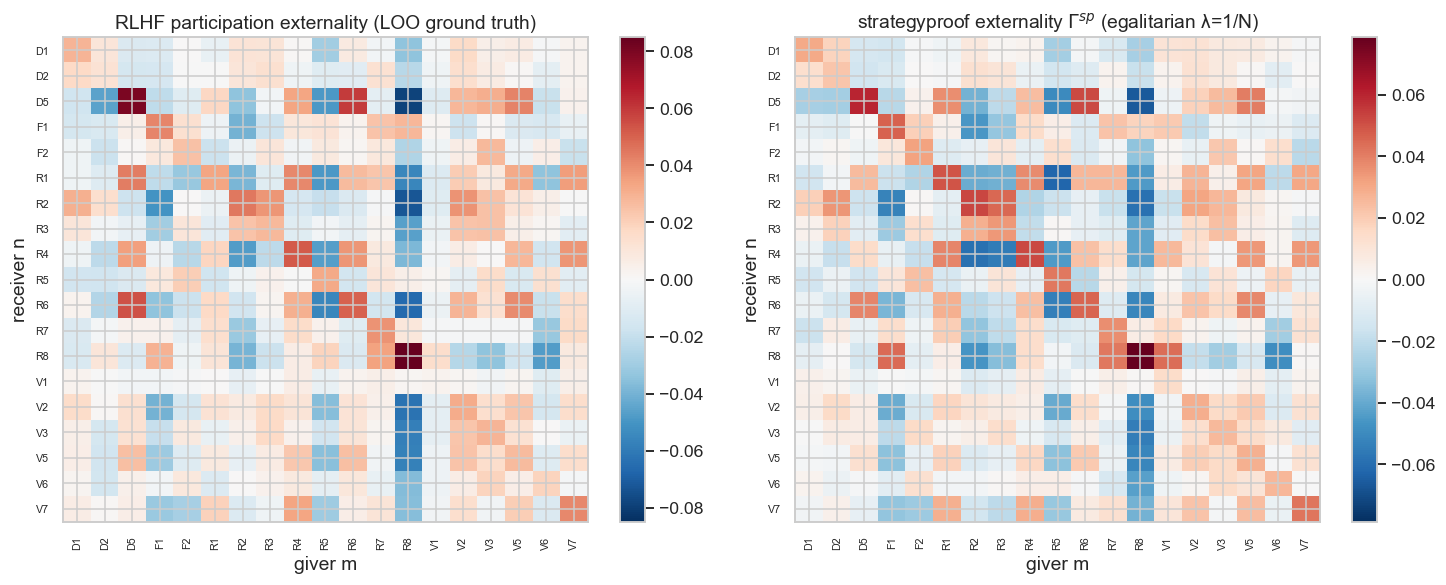

In [ ]:
# ── §9.3 strategyproof externality Γ^sp_{n,m} ────────────────────────────
# Γ^sp_{n,m} = λ_n · θ_m^T (ψ_n^* − ψ^sp_{λ,-n})
# where ψ^sp_{λ,-n} = (1/(1-λ_n)) Σ_{i≠n} λ_i ψ_i^*

def gamma_sp_matrix_fn(Theta_arr, psi_n_star_arr, lam):
    # Returns N×N matrix Γ^sp_{n,m}: row n = giver, col m = receiver (welfare shift to m from n's participation)
    N_loc = Theta_arr.shape[0]
    psi_sp = lam @ psi_n_star_arr                                      # (k,)
    G = np.zeros((N_loc, N_loc))
    for n in range(N_loc):
        if lam[n] <= 0:
            # n contributes 0 to the mixture → externality is 0
            continue
        # ψ^sp without n: re-normalize
        denom = 1.0 - lam[n]
        if denom <= 1e-15:
            # n is a single dictator; ψ^sp_{λ,-n} undefined; convention: 0
            psi_sp_minus_n = np.zeros_like(psi_sp)
        else:
            psi_sp_minus_n = (psi_sp - lam[n] * psi_n_star_arr[n]) / denom
        for m in range(N_loc):
            G[n, m] = lam[n] * float(Theta_arr[m] @ (psi_n_star_arr[n] - psi_sp_minus_n))
    return G

# Compute under each λ
print(f"{'λ choice':22s}  {'∥Γ^sp∥_F':>10s}  {'mean diag (own)':>15s}  {'mean off-diag':>13s}")
gamma_sp = {}
for label, r in results.items():
    G_sp = gamma_sp_matrix_fn(Theta, psi_n_star, r["lam"])
    gamma_sp[label] = G_sp
    diag = np.diag(G_sp)
    off  = G_sp[~np.eye(N_AGENTS, dtype=bool)]
    print(f"  {label:20s}  {np.linalg.norm(G_sp):>10.4f}  {diag.mean():>+15.5f}  {off.mean():>+13.5f}")

# Compare RLHF Γ to SP Γ at λ = eg (the most analogous case: equal weights)
G_sp_eg = gamma_sp["eg (1/N)"]
print()
print(f"comparison: RLHF Γ (LOO ground truth) vs SP Γ (random dictatorship):")
print(f"  ||RLHF Γ||_F        = {np.linalg.norm(Gamma):.4f}")
print(f"  ||SP-eg Γ||_F       = {np.linalg.norm(G_sp_eg):.4f}")
print(f"  cor(vec(RLHF Γ), vec(SP-eg Γ))  = "
      f"{np.corrcoef(Gamma.ravel(), G_sp_eg.ravel())[0,1]:+.4f}")

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))
vmax_rlhf = np.max(np.abs(Gamma))
im0 = axes[0].imshow(Gamma, cmap="RdBu_r", vmin=-vmax_rlhf, vmax=vmax_rlhf, aspect="auto")
axes[0].set_title("RLHF participation externality (LOO ground truth)")
axes[0].set_xticks(range(N_AGENTS)); axes[0].set_xticklabels(agent_ids, rotation=90, fontsize=7)
axes[0].set_yticks(range(N_AGENTS)); axes[0].set_yticklabels(agent_ids, fontsize=7)
axes[0].set_xlabel("giver m"); axes[0].set_ylabel("receiver n")
plt.colorbar(im0, ax=axes[0])

vmax_sp = np.max(np.abs(G_sp_eg))
# Note: G_sp[n,m] is row=giver, so transpose for "row=receiver, col=giver" convention used in §7
im1 = axes[1].imshow(G_sp_eg.T, cmap="RdBu_r", vmin=-vmax_sp, vmax=vmax_sp, aspect="auto")
axes[1].set_title(r"strategyproof externality $\Gamma^{sp}$ (egalitarian λ=1/N)")
axes[1].set_xticks(range(N_AGENTS)); axes[1].set_xticklabels(agent_ids, rotation=90, fontsize=7)
axes[1].set_yticks(range(N_AGENTS)); axes[1].set_yticklabels(agent_ids, fontsize=7)
axes[1].set_xlabel("giver m"); axes[1].set_ylabel("receiver n")
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()


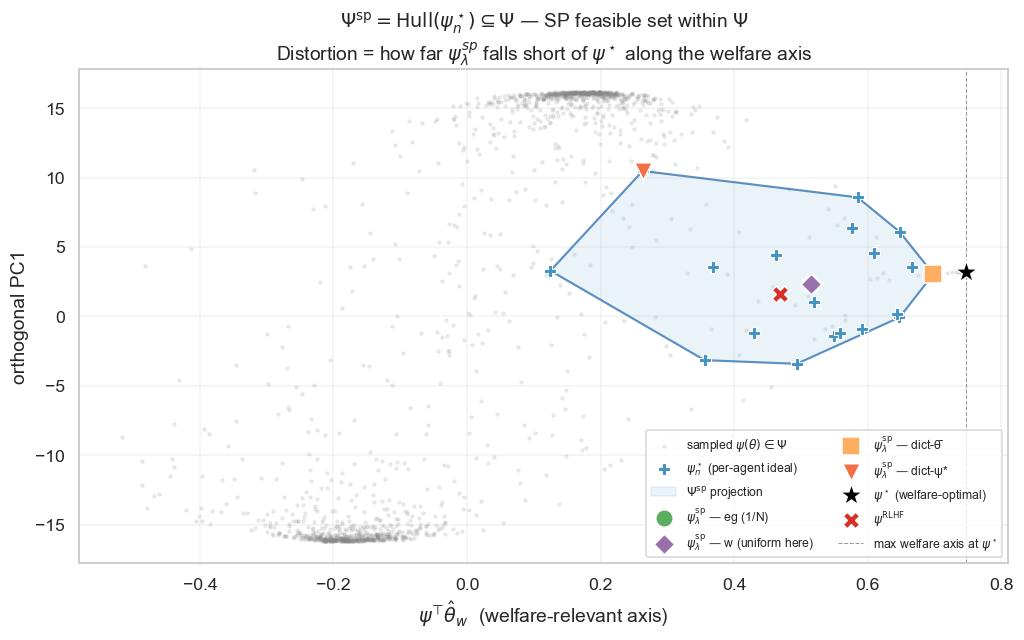


welfare-axis projection (x = ψ^T θ̄̂; W = ||θ̄|| · x):
  point                           x = ψ^T θ̄̂         W
  ψ^* (utilitarian)                    0.7472    0.9507
  ψ^sp (eg (1/N))                      0.5152    0.6555
  ψ^sp (w (uniform here))              0.5152    0.6555
  ψ^sp (dict-θ̄)                       0.6983    0.8885
  ψ^sp (dict-ψ*)                       0.2629    0.3345
  ψ^RLHF (β=1)                         0.4690    0.5968


In [ ]:
# ── §9.4 visualize Ψ^sp inside Ψ along the welfare axis ──────────────────
# Welfare axis: project onto θ̄/||θ̄||.  In this projection ψ* is at the
# boundary of Ψ; ψ^sp_λ values lie inside the SP hull, which is itself inside Ψ.

x_axis = theta_bar / np.linalg.norm(theta_bar)
psi_perp_ref = psi_n_star - (psi_n_star @ x_axis)[:, None] * x_axis
y_axis = PCA(n_components=1).fit(psi_perp_ref).components_[0]

def to_2d_w(v):
    v = np.atleast_2d(v); return np.column_stack([v @ x_axis, v @ y_axis])

# Resample interior of Ψ for context (reuse approach from §5)
rng_p = np.random.default_rng(7)
samples_t = [theta_bar, theta_rlhf] + [Theta[n] for n in range(N_AGENTS)]
for _ in range(1500):
    d = rng_p.standard_normal(K_DIM); d /= np.linalg.norm(d)
    samples_t.append(rng_p.uniform(0, 8) * d)
for b in np.linspace(0.05, 100, 200):
    samples_t.append(b * theta_bar)
samples_t = np.vstack(samples_t)
psi_samples_p = np.array([psi_fn(th, alpha_train) for th in samples_t])
psi_2d = to_2d_w(psi_samples_p)

# Ψ^sp = convex hull of ψ_n^* — in 2D projection, plot the hull of their 2D images
psi_n_2d = to_2d_w(psi_n_star)

fig, ax = plt.subplots(figsize=(9.5, 6.0))

# Background: Ψ samples (light)
ax.scatter(psi_2d[:, 0], psi_2d[:, 1], s=4, alpha=0.13, color="#888",
           label=r"sampled $\psi(\theta) \in \Psi$")

# Per-agent ψ*_n
ax.scatter(psi_n_2d[:, 0], psi_n_2d[:, 1], s=55, color="#4393c3", marker="P",
           edgecolor="white", linewidth=0.7, zorder=4, label=r"$\psi^\star_n$ (per-agent ideal)")

# Convex hull of ψ_n* in 2D projection (visualizes Ψ^sp's projection)
try:
    hull_sp = ConvexHull(psi_n_2d)
    hull_pts = np.append(psi_n_2d[hull_sp.vertices], psi_n_2d[hull_sp.vertices[:1]], axis=0)
    ax.fill(hull_pts[:, 0], hull_pts[:, 1], color="#92c5de", alpha=0.20,
            label=r"$\Psi^{\rm sp}$ projection")
    ax.plot(hull_pts[:, 0], hull_pts[:, 1], color="#2166ac", lw=1.4, alpha=0.7)
except Exception:
    pass

# Each λ choice's ψ^sp
markers = {"eg (1/N)": ("o", "#5aae61", 130),
           "w (uniform here)": ("D", "#9970ab", 90),
           "dict-θ̄": ("s", "#fdae61", 130),
           "dict-ψ*": ("v", "#f46d43", 130)}
for label, r in results.items():
    p2 = to_2d_w(r["psi_sp"])[0]
    m, c, s = markers[label]
    ax.scatter(*p2, s=s, color=c, marker=m, edgecolor="white", linewidth=1.0, zorder=6,
               label=fr"$\psi^{{\rm sp}}_\lambda$ — {label}")

# Reference: ψ* and ψ_RLHF
ax.scatter(*to_2d_w(psi_star_util)[0], s=240, color="black", marker="*",
           edgecolor="white", linewidth=1.0, zorder=7, label=r"$\psi^\star$ (welfare-optimal)")
ax.scatter(*to_2d_w(psi_rlhf_full)[0], s=120, color="#d73027", marker="X",
           edgecolor="white", linewidth=1.0, zorder=7, label=r"$\psi^{\rm RLHF}$")

# Welfare-axis label
x_star = float(psi_star_util @ x_axis)
ax.axvline(x_star, color="black", ls="--", lw=0.7, alpha=0.4,
           label=fr"max welfare axis at $\psi^\star$")

ax.set_xlabel(r"$\psi^\top \hat\theta_w$  (welfare-relevant axis)")
ax.set_ylabel("orthogonal PC1")
ax.set_title(r"$\Psi^{\rm sp} = \mathrm{Hull}(\psi^\star_n) \subseteq \Psi$ — SP feasible set within $\Psi$"
             "\nDistortion = how far $\\psi^{sp}_\\lambda$ falls short of $\\psi^\\star$ along the welfare axis")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8.0, loc="lower right", ncol=2)
plt.tight_layout()
plt.show()

# Welfare-axis summary
print(f"\nwelfare-axis projection (x = ψ^T θ̄̂; W = ||θ̄|| · x):")
print(f"  {'point':28s}  {'x = ψ^T θ̄̂':>13s}  {'W':>8s}")
print(f"  {'ψ^* (utilitarian)':28s}  {x_star:>13.4f}  {x_star * np.linalg.norm(theta_bar):>8.4f}")
for label, r in results.items():
    x_lp = float(r["psi_sp"] @ x_axis)
    print(f"  {f'ψ^sp ({label})':28s}  {x_lp:>13.4f}  {x_lp * np.linalg.norm(theta_bar):>8.4f}")
print(f"  {'ψ^RLHF (β=1)':28s}  {float(psi_rlhf_full @ x_axis):>13.4f}  "
      f"{float(psi_rlhf_full @ x_axis) * np.linalg.norm(theta_bar):>8.4f}")


---

**§9 checkpoint.** Verify:

- $\psi^{\rm sp}_\lambda$ lies inside $\Psi$ for all four $\lambda$ choices (since each is a convex combination of $\psi^\star_n \in \Psi$).
- Theorem 2 sanity: $W$ via $\theta^{\rm sp}_\lambda$ matches $W$ via $\psi^{\rm sp}_\lambda$ to numerical precision (the $\psi$-inversion succeeds).
- Distortion is bounded for **dict-θ̄** (the welfare-maxing dictator) and typically larger (worse) for the egalitarian/welfare-weighted random dictatorships — as expected from the convex-hull argument that egalitarian mixtures of vertices fall short of the welfare-optimal vertex.
- The strategyproof externality $\Gamma^{\rm sp}_{n,m}$ has zero rows for any $n$ with $\lambda_n = 0$ (a non-participating dictator imposes no externality).
- Comparing RLHF $\Gamma$ to SP $\Gamma$: both are externality matrices but they capture different mechanisms (anonymous BTL pooling vs. random dictatorship). The correlation between their entries tells you whether the same agents are "tyrants" under both mechanisms.


### 9.5 Cross-mechanism externalities by k-means cluster

Compare how three mechanisms distribute alignment externalities across the same KMeans(k=4) preference clusters from §7.6:

| mechanism | deployed impact | externality of giver $m$ on receiver $n$ |
|---|---|---|
| **Utilitarian** | $\psi^\star(\bar\theta)$ (welfare-optimal limit) | $\theta_n^\top(\psi^\star(\bar\theta) - \psi^\star(\bar\theta_{-m}))$ |
| **RLHF** | $\psi(\hat\theta)$ at β=1 (anonymous BTL) | $\theta_n^\top(\psi(\hat\theta) - \psi(\hat\theta_{-m}))$ |
| **SP-egalitarian** | $\sum_n \tfrac{1}{N}\psi_n^\star$ (random dictatorship) | $\lambda_m\,\theta_n^\top(\psi_m^\star - \psi^{\rm sp}_{\lambda,-m})$ |

For each mechanism we build the $N\times N$ matrix (rows=receiver, cols=giver), reorder rows/cols by cluster, and aggregate to a 4×4 cluster summary. The within-vs-across signal $\Delta = \overline{\Gamma}_{\rm within} - \overline{\Gamma}_{\rm across}$ tells us whether each mechanism amplifies or dampens within-cluster solidarity.


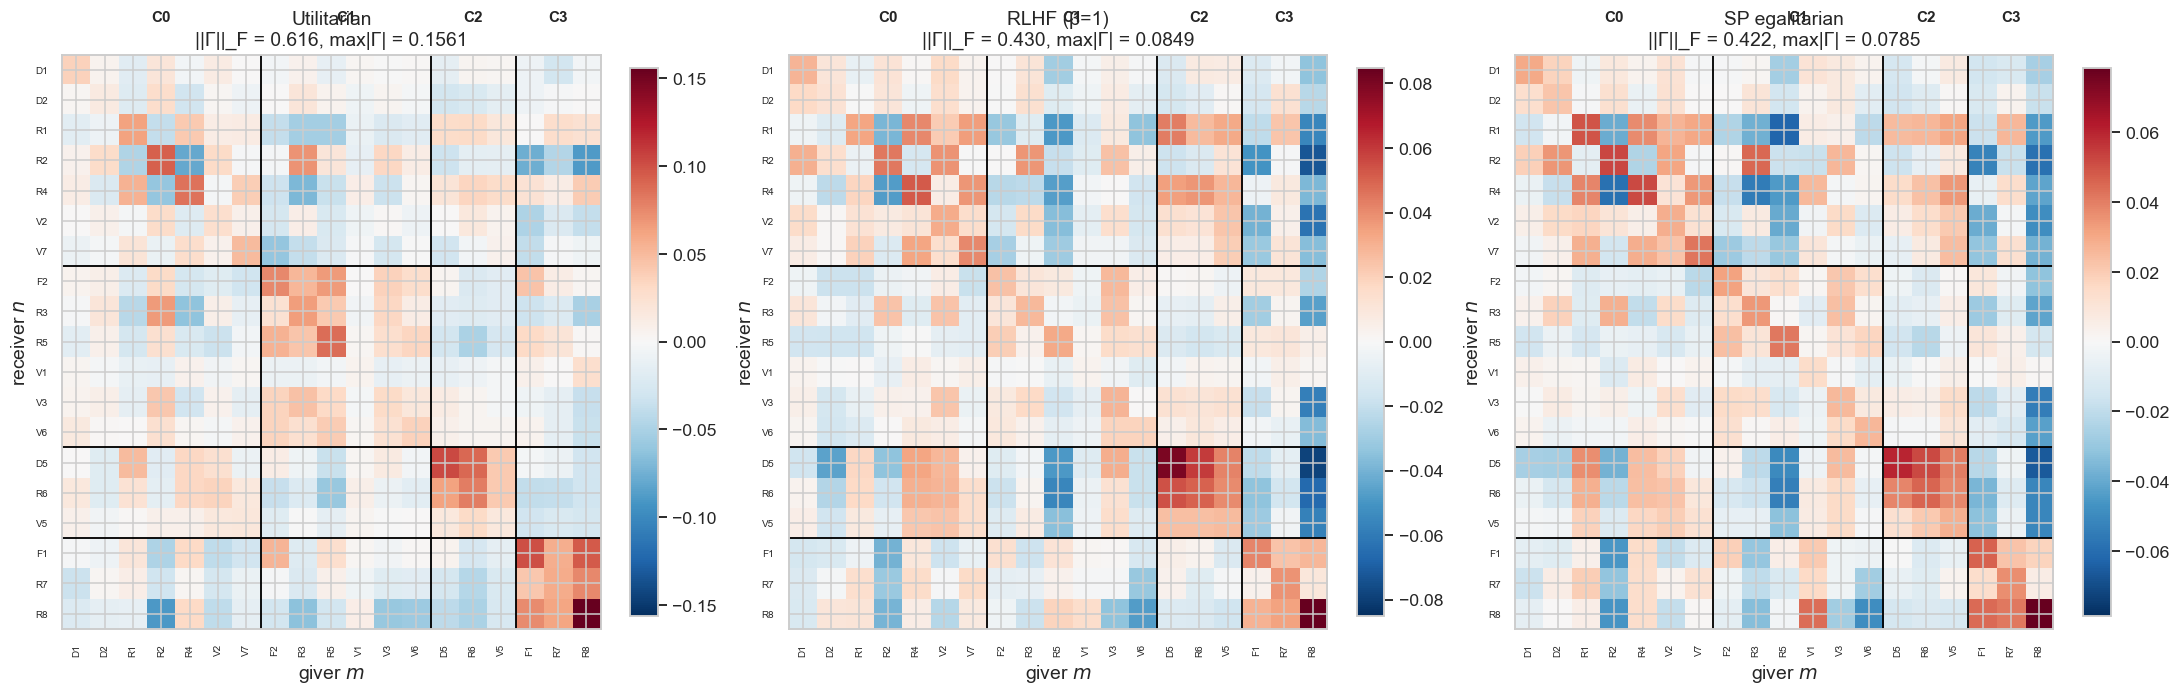

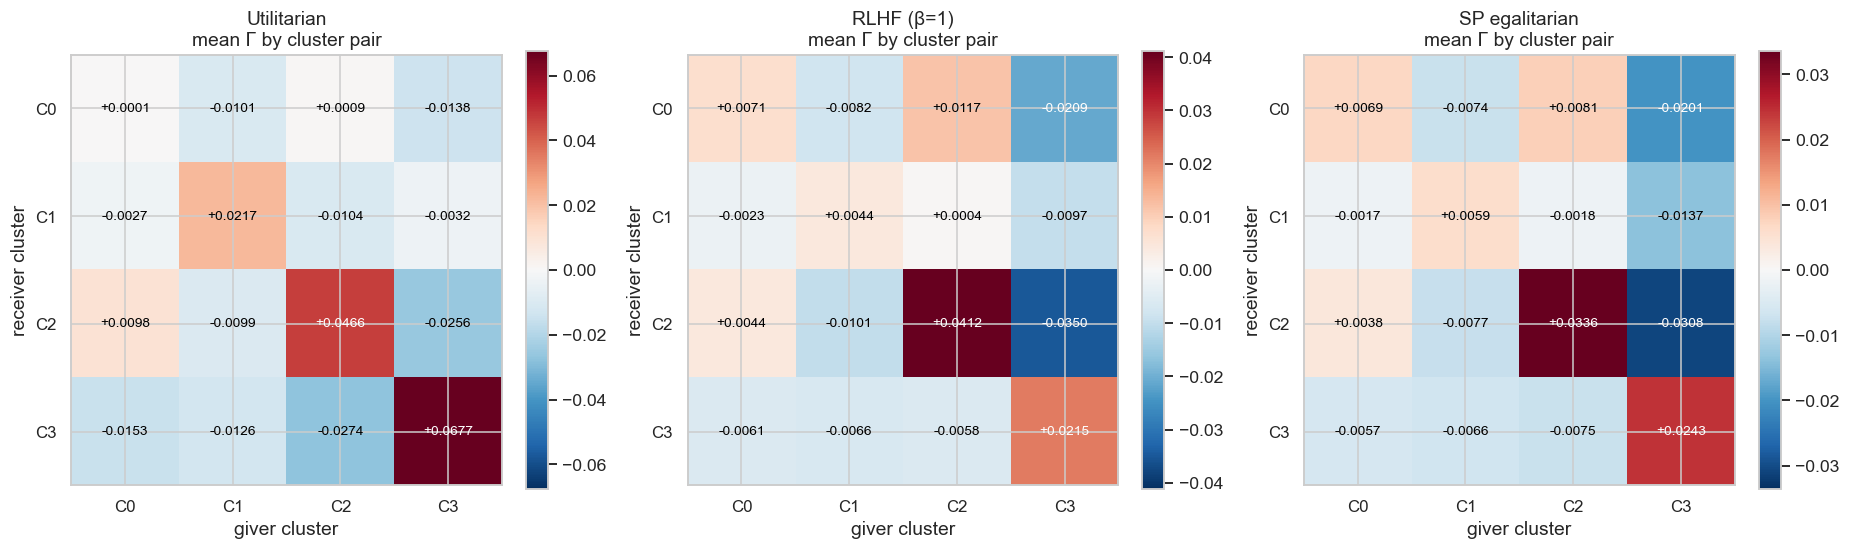

mechanism             ||Γ||_F  within mean  across mean  within − across  cor with RLHF
  Utilitarian          0.6158     +0.03400     -0.01002         +0.04402        +0.7385
  RLHF (β=1)           0.4300     +0.01854     -0.00735         +0.02589        +1.0000
  SP egalitarian       0.4222     +0.01768     -0.00760         +0.02527        +0.9303


In [ ]:
# ── §9.5 cross-mechanism externalities by k-means cluster ────────────────

# ===== Utilitarian Γ via LOO on θ̄ =====
def compute_gamma_util(Theta_arr, weights_arr, alpha_dep):
    # Γ^util[n, m] = θ_n^T (ψ*(θ̄) − ψ*(θ̄_{-m}))  with θ̄_{-m} = welfare-mean over n≠m, renormalized.
    N_loc = Theta_arr.shape[0]
    theta_bar_loc = weights_arr @ Theta_arr
    psi_star_full = psi_star_fn(theta_bar_loc, alpha_dep)
    G = np.zeros((N_loc, N_loc))
    for m in range(N_loc):
        w_minus_m = weights_arr.copy()
        w_minus_m[m] = 0.0
        if w_minus_m.sum() <= 1e-15:
            continue
        w_minus_m = w_minus_m / w_minus_m.sum()
        theta_bar_minus_m = w_minus_m @ Theta_arr
        psi_star_minus_m = psi_star_fn(theta_bar_minus_m, alpha_dep)
        delta_psi = psi_star_full - psi_star_minus_m
        G[:, m] = Theta_arr @ delta_psi
    return G

Gamma_util = compute_gamma_util(Theta, weights, alpha_train)

# ===== RLHF Γ (already computed in §7 as `Gamma`) =====
Gamma_rlhf = Gamma                                      # alias, rows=receiver, cols=giver

# ===== Strategyproof Γ (egalitarian λ), receiver/giver convention =====
def compute_gamma_sp(Theta_arr, psi_n_star_arr, lam):
    N_loc = Theta_arr.shape[0]
    psi_sp = lam @ psi_n_star_arr
    G = np.zeros((N_loc, N_loc))
    for m in range(N_loc):
        if lam[m] <= 0:
            continue
        denom = 1.0 - lam[m]
        psi_sp_minus_m = ((psi_sp - lam[m] * psi_n_star_arr[m]) / denom
                          if denom > 1e-15 else np.zeros_like(psi_sp))
        diff = psi_n_star_arr[m] - psi_sp_minus_m
        G[:, m] = lam[m] * (Theta_arr @ diff)
    return G

lam_eg = np.full(N_AGENTS, 1.0 / N_AGENTS)
Gamma_sp = compute_gamma_sp(Theta, psi_n_star, lam_eg)

# ===== Reuse k-means clusters from §7.6 =====
order_c = np.lexsort((agent_ids, clusters))
labels_ord_c = agent_ids[order_c]
clust_ord_c = clusters[order_c]
boundaries_c2 = [i for i in range(1, len(clust_ord_c)) if clust_ord_c[i] != clust_ord_c[i-1]]

# ===== Side-by-side full heatmaps =====
mechs = [
    ("Utilitarian",     Gamma_util),
    ("RLHF (β=1)",      Gamma_rlhf),
    ("SP egalitarian",  Gamma_sp),
]

vmax_global = max(np.max(np.abs(G)) for _, G in mechs)
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
for ax, (name, G) in zip(axes, mechs):
    G_ord = G[np.ix_(order_c, order_c)]
    vmax_local = np.max(np.abs(G))
    im = ax.imshow(G_ord, cmap="RdBu_r", vmin=-vmax_local, vmax=vmax_local, aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks(range(N_AGENTS)); ax.set_xticklabels(labels_ord_c, rotation=90, fontsize=6.5)
    ax.set_yticks(range(N_AGENTS)); ax.set_yticklabels(labels_ord_c, fontsize=6.5)
    ax.set_xlabel("giver $m$"); ax.set_ylabel("receiver $n$")
    for b in boundaries_c2:
        ax.axhline(b - 0.5, color="black", lw=1.2)
        ax.axvline(b - 0.5, color="black", lw=1.2)
    for c in sorted(np.unique(clust_ord_c)):
        pos = np.where(clust_ord_c == c)[0]
        mid = (pos[0] + pos[-1]) / 2
        ax.annotate(c, xy=(mid, -1.5), fontsize=10, fontweight="bold",
                    ha="center", va="bottom", annotation_clip=False)
    ax.set_title(f"{name}\n||Γ||_F = {np.linalg.norm(G):.3f}, max|Γ| = {vmax_local:.4f}")
plt.tight_layout()
plt.show()

# ===== 4×4 cluster summary for each mechanism =====
unique_clust = sorted(np.unique(clusters))
n_c = len(unique_clust)

def cluster_summary(G):
    S = np.zeros((n_c, n_c))
    for i, cn in enumerate(unique_clust):
        for j, cm in enumerate(unique_clust):
            block = G[np.ix_(clusters == cn, clusters == cm)]
            if i == j:
                offd = block[~np.eye(block.shape[0], dtype=bool)]
                S[i, j] = offd.mean() if offd.size > 0 else 0.0
            else:
                S[i, j] = block.mean()
    return S

summaries = [(name, cluster_summary(G)) for name, G in mechs]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
for ax, (name, S) in zip(axes, summaries):
    vmax = np.max(np.abs(S))
    im = ax.imshow(S, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks(range(n_c)); ax.set_xticklabels(unique_clust, fontsize=11)
    ax.set_yticks(range(n_c)); ax.set_yticklabels(unique_clust, fontsize=11)
    ax.set_xlabel("giver cluster"); ax.set_ylabel("receiver cluster")
    ax.set_title(f"{name}\nmean Γ by cluster pair")
    for i in range(n_c):
        for j in range(n_c):
            ax.text(j, i, f"{S[i,j]:+.4f}",
                    ha="center", va="center", fontsize=9,
                    color="white" if abs(S[i,j]) > 0.5*vmax else "black")
plt.tight_layout()
plt.show()

# ===== Numerical comparison =====
print(f"{'mechanism':18s}  {'||Γ||_F':>9s}  {'within mean':>11s}  {'across mean':>11s}  {'within − across':>15s}  {'cor with RLHF':>13s}")
off_mask = ~np.eye(n_c, dtype=bool)
for (name, G), (_, S) in zip(mechs, summaries):
    within = np.diag(S).mean()
    across = S[off_mask].mean()
    cor_rlhf = np.corrcoef(G.ravel(), Gamma_rlhf.ravel())[0, 1]
    print(f"  {name:16s}  {np.linalg.norm(G):>9.4f}  {within:>+11.5f}  "
          f"{across:>+11.5f}  {within - across:>+15.5f}  {cor_rlhf:>+13.4f}")


### 9.6 Same comparison at matched β = ∞ (apples-to-apples)

Re-run §9.5 with **all three mechanisms** evaluated at the deterministic limit, so the asymmetric β convention isn't doing the heavy lifting. The only change vs §9.5 is RLHF: instead of $\psi(\hat\theta)$ at $\beta=1$ we now use

$$\psi^\star(\hat\theta) \;=\; \tfrac12\,\mathbb E_z[\alpha_z\,\mathrm{sign}(\alpha_z^\top\hat\theta)]$$

and the LOO counterpart $\psi^\star(\hat\theta_{-m})$. This isolates the **directional** distortion from the regularization-magnitude effect.

Expected pattern (from §6.4): at β=∞, RLHF and Utilitarian should be nearly identical (only 1.27% welfare gap), so their externality matrices and cluster summaries should converge.


In [ ]:
# ── §9.6 cluster comparison at β = ∞ for all three mechanisms ────────────

# ===== RLHF at β=∞ (deterministic): use sign instead of sigmoid =====
def psi_inf_fn(theta_c, alpha_dep):
    # 1/2 E[ alpha_z * sign(alpha_z^T theta_c) ]
    s = np.sign(alpha_dep @ theta_c)
    return 0.5 * (alpha_dep * s[:, None]).mean(axis=0)

psi_rlhf_inf = psi_inf_fn(theta_rlhf, alpha_train)
psi_loo_inf  = np.array([psi_inf_fn(theta_loo[m], alpha_train) for m in range(N_AGENTS)])
delta_psi_m_inf = psi_rlhf_inf[None, :] - psi_loo_inf
Gamma_rlhf_inf = Theta @ delta_psi_m_inf.T

# Γ^util and Γ^sp from §9.5 are already at β=∞ (Util uses ψ*, SP uses ψ_n*)
mechs_inf = [
    ("Utilitarian (β=∞)",     Gamma_util),
    ("RLHF (β=∞)",            Gamma_rlhf_inf),
    ("SP egalitarian",        Gamma_sp),
]

# Frobenius + welfare each mechanism delivers
print(f"{'mechanism':22s}  {'||Γ||_F':>9s}  {'W achieved':>11s}  {'distortion':>11s}")
W_star_v = float(theta_bar @ psi_star_fn(theta_bar, alpha_train))
W_rlhf_inf = float(theta_bar @ psi_rlhf_inf)
W_sp_eg = float(theta_bar @ (lam_eg @ psi_n_star))
W_each = {"Utilitarian (β=∞)": W_star_v, "RLHF (β=∞)": W_rlhf_inf, "SP egalitarian": W_sp_eg}
for name, G in mechs_inf:
    W = W_each[name]
    print(f"  {name:20s}  {np.linalg.norm(G):>9.4f}  {W:>11.6f}  {W_star_v / W if W > 0 else float('inf'):>11.4f}")

# ===== Reorder by k-means cluster + plot 3 full heatmaps =====
order_c = np.lexsort((agent_ids, clusters))
labels_ord_c = agent_ids[order_c]
clust_ord_c = clusters[order_c]
boundaries_c2 = [i for i in range(1, len(clust_ord_c)) if clust_ord_c[i] != clust_ord_c[i-1]]

fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
for ax, (name, G) in zip(axes, mechs_inf):
    G_ord = G[np.ix_(order_c, order_c)]
    vmax_local = np.max(np.abs(G))
    im = ax.imshow(G_ord, cmap="RdBu_r", vmin=-vmax_local, vmax=vmax_local, aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks(range(N_AGENTS)); ax.set_xticklabels(labels_ord_c, rotation=90, fontsize=6.5)
    ax.set_yticks(range(N_AGENTS)); ax.set_yticklabels(labels_ord_c, fontsize=6.5)
    ax.set_xlabel("giver $m$"); ax.set_ylabel("receiver $n$")
    for b in boundaries_c2:
        ax.axhline(b - 0.5, color="black", lw=1.2)
        ax.axvline(b - 0.5, color="black", lw=1.2)
    for c in sorted(np.unique(clust_ord_c)):
        pos = np.where(clust_ord_c == c)[0]
        mid = (pos[0] + pos[-1]) / 2
        ax.annotate(c, xy=(mid, -1.5), fontsize=10, fontweight="bold",
                    ha="center", va="bottom", annotation_clip=False)
    ax.set_title(f"{name}\n||Γ||_F = {np.linalg.norm(G):.3f}")
plt.tight_layout()
plt.show()

# ===== 4×4 cluster summaries =====
unique_clust = sorted(np.unique(clusters))
n_c = len(unique_clust)

def cluster_summary(G):
    S = np.zeros((n_c, n_c))
    for i, cn in enumerate(unique_clust):
        for j, cm in enumerate(unique_clust):
            block = G[np.ix_(clusters == cn, clusters == cm)]
            if i == j:
                offd = block[~np.eye(block.shape[0], dtype=bool)]
                S[i, j] = offd.mean() if offd.size > 0 else 0.0
            else:
                S[i, j] = block.mean()
    return S

summaries_inf = [(name, cluster_summary(G)) for name, G in mechs_inf]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
for ax, (name, S) in zip(axes, summaries_inf):
    vmax = np.max(np.abs(S))
    im = ax.imshow(S, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks(range(n_c)); ax.set_xticklabels(unique_clust, fontsize=11)
    ax.set_yticks(range(n_c)); ax.set_yticklabels(unique_clust, fontsize=11)
    ax.set_xlabel("giver cluster"); ax.set_ylabel("receiver cluster")
    ax.set_title(f"{name}\nmean Γ by cluster pair")
    for i in range(n_c):
        for j in range(n_c):
            ax.text(j, i, f"{S[i,j]:+.4f}",
                    ha="center", va="center", fontsize=9,
                    color="white" if abs(S[i,j]) > 0.5*vmax else "black")
plt.tight_layout()
plt.show()

# ===== Numerical comparison (and contrast with §9.5's RLHF at β=1) =====
off_mask = ~np.eye(n_c, dtype=bool)
print(f"\n{'mechanism':22s}  {'||Γ||_F':>9s}  {'within mean':>11s}  {'across mean':>11s}  {'within − across':>15s}  {'cor with Util':>13s}")
for (name, G), (_, S) in zip(mechs_inf, summaries_inf):
    within = np.diag(S).mean()
    across = S[off_mask].mean()
    cor_util = np.corrcoef(G.ravel(), Gamma_util.ravel())[0, 1]
    print(f"  {name:20s}  {np.linalg.norm(G):>9.4f}  {within:>+11.5f}  "
          f"{across:>+11.5f}  {within - across:>+15.5f}  {cor_util:>+13.4f}")

# Direct contrast: RLHF before vs after β switch
print(f"\nRLHF at β=1   vs   RLHF at β=∞   (cluster summary diagonals):")
S_b1  = cluster_summary(Gamma_rlhf)
S_inf = cluster_summary(Gamma_rlhf_inf)
print(f"  cluster   within(β=1)   within(β=∞)   ratio")
for c in unique_clust:
    j = unique_clust.index(c)
    print(f"  {c:>7s}    {S_b1[j,j]:>+9.5f}     {S_inf[j,j]:>+9.5f}     "
          f"{S_inf[j,j] / S_b1[j,j] if S_b1[j,j] != 0 else float('nan'):>5.2f}x")

print(f"\ncor(Γ^RLHF_β=∞, Γ^Util) = "
      f"{np.corrcoef(Gamma_rlhf_inf.ravel(), Gamma_util.ravel())[0,1]:+.4f}")
print(f"cor(Γ^RLHF_β=1, Γ^Util) = "
      f"{np.corrcoef(Gamma_rlhf.ravel(), Gamma_util.ravel())[0,1]:+.4f}")
print(f"  → at β=∞, RLHF's externality structure should sit much closer to Utilitarian.")
